<div style="
    text-align:center;
    padding:20px;
    background:linear-gradient(90deg,#020617,#0f172a,#1e293b);
    border-left:3px solid #06b6d4;
    border-radius:10px;
    font-family:'Segoe UI',sans-serif;
">

<h1 style="
    color:#06b6d4;
    font-size:43px;
    margin-bottom:6px;
    font-weight:600;
">
Marketing Campaign Data Pipeline
</h1>

<p style="
    color:#e2e8f0;
    font-size:20px;
    letter-spacing:1px;
    margin-top:0;
">
End-to-End Analysis: Operations, QA & Sales Tracking
</p>

<hr style="
    width:90px;
    border:2px solid #06b6d4;
">

<p style="
    color:#94a3b8;
    font-size:14px;
">
Data Understanding • Cleaning • Exploratory Analysis • Forecasting 
</p>

</div>

---
# Business Understanding

This dataset contains operational, quality assurance, and sales performance records for a marketing campaign.
The dataset contains **26 columns** / **1184 Rows**                                           
The business objectives are:

- Understand campaign performance.
- Identify top-performing agents.
- Evaluate quality assurance impact on sales.
- Analyze conversion performance.
- Forecast future campaign results.

Key business questions:

1. Which agents names , team lead names, closing agents ?
2. which city have more clients?
3. Gender rate?
4. there are many date what the data pattern ? 
5. Does quality score influence conversion?
6. Which products perform best?
7. How is campaign performance changing over time?
8. What can be expected in future periods?

--- 

# import libraries 

In [566]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
from datetime import datetime
import plotly.express as px
warnings.filterwarnings("ignore")
from prophet import Prophet
import pickle
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
import os

 # **phase 1**: Data Understanding & Cleaning


### collection data

In [368]:
dataset = pd.read_csv('../data/sample data.csv')
dataset.head()

,Quality Agent Name,Assign Date,Work Duration,Recording link,Validation,Finish Date,QA Feedback,Validated ?,Validation Date,Quality Score %,...,Client,Opening Status,Team Leader,Closing Status,Closer Name,Date of Sale,Comment,Creation Date,Date of Payment,Pricing List
0,Jude,28-04-2026,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,...,Med Guard Alert,Transferred,Kylie Lopez,Approved,Summer Hudson,21-04-2026,PT Paid today,21-04-2026,21-04-2026,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,...,Med Guard Alert,Transferred,Timothy Williams,Approved,Summer Hudson,22-04-2026,Pt will pay on 05/03/2026\n\nPayment sent to t...,22-04-2026,15-05-2026,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,...,Med Guard Alert,Transferred,Tim ford,Approved,Maeve White,21-04-2026,PT Paid Today,23-04-2026,21-04-2026,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,...,Med Guard Alert,Transferred,Kylie Lopez,Approved,Summer Hudson,21-04-2026,PT Paid today,23-04-2026,21-04-2026,NaN
4,Victoria,1/5/2026,NaN,NaN,NaN,1/5/2026,NaN,1,NaN,NaN,...,Med Guard Alert,Transferred,Sarah Adams,Approved,Maeve White,22-04-2026,PT Paid Today,22-04-2026,22-04-2026,NaN


In [369]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1184 entries, 0 to 1183
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Quality Agent Name  192 non-null    object 
 1   Assign Date         192 non-null    object 
 2   Work Duration       148 non-null    float64
 3   Recording link      53 non-null     object 
 4   Validation          149 non-null    object 
 5   Finish Date         152 non-null    object 
 6   QA Feedback         150 non-null    object 
 7   Validated ?         1184 non-null   int64  
 8   Validation Date     149 non-null    object 
 9   Quality Score %     152 non-null    object 
 10  State               1154 non-null   object 
 11  Zip code            1184 non-null   int64  
 12  DOB                 1183 non-null   object 
 13  City                1148 non-null   object 
 14  Product             1168 non-null   object 
 15  Gender              1149 non-null   object 
 16  Opener

sounds good columns structure but are this all useful?

### general information

In [370]:
print(f"Rows: {dataset.shape[0]}")
print(f"Columns: {dataset.shape[1]}")

Rows: 1184
Columns: 27


In [371]:
dataset.columns.tolist()

['Quality Agent Name',
 'Assign Date',
 'Work Duration',
 'Recording link',
 'Validation',
 'Finish Date',
 'QA Feedback',
 'Validated ?',
 'Validation Date',
 'Quality Score %',
 'State',
 'Zip code',
 'DOB',
 'City',
 'Product',
 'Gender',
 'Opener Name',
 'Client',
 'Opening Status',
 'Team Leader',
 'Closing Status',
 'Closer Name',
 'Date of Sale',
 'Comment',
 'Creation Date',
 'Date of Payment',
 'Pricing List']

In [372]:
dataset.describe()

,Work Duration,Validated ?,Zip code
count,148.000000,1184.000000,1.184000e+03
mean,15.925676,0.125000,4.509291e+05
std,6.819431,0.330859,1.396077e+07
min,6.000000,0.000000,0.000000e+00
25%,10.000000,0.000000,1.427875e+04
50%,15.000000,0.000000,3.956350e+04
75%,20.000000,0.000000,7.280825e+04
max,38.000000,1.000000,4.804242e+08


In [373]:
dataset.describe(include='object')

,Quality Agent Name,Assign Date,Recording link,Validation,Finish Date,QA Feedback,Validation Date,Quality Score %,State,DOB,...,Client,Opening Status,Team Leader,Closing Status,Closer Name,Date of Sale,Comment,Creation Date,Date of Payment,Pricing List
count,192,192,53,149,152,150,149,152,1154,1183,...,1183,1183,1182,1085,1080,551,1147,1183,502,455
unique,6,5,51,3,6,136,5,34,125,1046,...,2,5,18,8,13,39,884,42,58,9
top,Dan,29-04-2026,https://drive.google.com/drive/folders/1QPNPHW...,Smooth,29-04-2026,Greeting was pretty good and the agent went st...,29-04-2026,90,CA,2/6/2026,...,Med Guard Alert,Transferred,Chris Heisenberg,Approved,Summer Hudson,1/6/2026,PT Paid Today,23-04-2026,2/6/2026,$39.95/Month
freq,45,94,2,107,79,7,77,33,151,10,...,841,977,207,387,272,30,77,73,38,154


wow it contain many missing values 

In [374]:
summary = pd.DataFrame({
    "Column":dataset.columns,
    "Data Type":dataset.dtypes.values,
    "Missing":dataset.isnull().sum().values,
    "Missing %":round(dataset.isnull().mean()*100,2).values,
    "Unique Values":dataset.nunique().values
})

summary

,Column,Data Type,Missing,Missing %,Unique Values
0,Quality Agent Name,object,992,83.78,6
1,Assign Date,object,992,83.78,5
2,Work Duration,float64,1036,87.50,27
3,Recording link,object,1131,95.52,51
4,Validation,object,1035,87.42,3
5,Finish Date,object,1032,87.16,6
6,QA Feedback,object,1034,87.33,136
7,Validated ?,int64,0,0.00,2
8,Validation Date,object,1035,87.42,5
9,Quality Score %,object,1032,87.16,34


### start pipeline cleaning dataset

#### missing values

In [375]:
print(dataset.isnull().sum())


Quality Agent Name     992
Assign Date            992
Work Duration         1036
Recording link        1131
Validation            1035
Finish Date           1032
QA Feedback           1034
Validated ?              0
Validation Date       1035
Quality Score %       1032
State                   30
Zip code                 0
DOB                      1
City                    36
Product                 16
Gender                  35
Opener Name              3
Client                   1
Opening Status           1
Team Leader              2
Closing Status          99
Closer Name            104
Date of Sale           633
Comment                 37
Creation Date            1
Date of Payment        682
Pricing List           729
dtype: int64


In [376]:
print(round(dataset.isnull().mean()*100,2))

Quality Agent Name    83.78
Assign Date           83.78
Work Duration         87.50
Recording link        95.52
Validation            87.42
Finish Date           87.16
QA Feedback           87.33
Validated ?            0.00
Validation Date       87.42
Quality Score %       87.16
State                  2.53
Zip code               0.00
DOB                    0.08
City                   3.04
Product                1.35
Gender                 2.96
Opener Name            0.25
Client                 0.08
Opening Status         0.08
Team Leader            0.17
Closing Status         8.36
Closer Name            8.78
Date of Sale          53.46
Comment                3.12
Creation Date          0.08
Date of Payment       57.60
Pricing List          61.57
dtype: float64


there are a red flag columns have above 90% missing values 
for the any columns have above 30% that can be delete it, and if less that can be fil it with mode or mid 

#### duplicated values

In [377]:
print(dataset.duplicated().sum())

1


In [378]:
dataset[dataset.duplicated()]

,Quality Agent Name,Assign Date,Work Duration,Recording link,Validation,Finish Date,QA Feedback,Validated ?,Validation Date,Quality Score %,...,Client,Opening Status,Team Leader,Closing Status,Closer Name,Date of Sale,Comment,Creation Date,Date of Payment,Pricing List
507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,...,Med Guard Alert,Transferred,Dona Johnson,Approved,Lilly Williams,6/5/2026,paid on 05/06/2026,6/5/2026,6/5/2026,NaN


one column with duplicated

#### unique values

In [379]:
print(dataset.nunique().sort_values(ascending=False))

Zip code              1048
DOB                   1046
City                   916
Comment                884
QA Feedback            136
State                  125
Opener Name            103
Date of Payment         58
Recording link          51
Creation Date           42
Date of Sale            39
Quality Score %         34
Work Duration           27
Team Leader             18
Closer Name             13
Pricing List             9
Closing Status           8
Quality Agent Name       6
Finish Date              6
Opening Status           5
Assign Date              5
Validation Date          5
Validation               3
Validated ?              2
Client                   2
Product                  2
Gender                   2
dtype: int64


there are 2 products only   (smartwatch, necklace)                                  
there are 2 client only 
have 916 city                                               
there are 13 closer , 18 team leader!, 103 opener! ,  

#### numerical columns

In [380]:
num_cols = dataset.select_dtypes(
    include=['int64','float64']
).columns

num_cols

Index(['Work Duration', 'Validated ?', 'Zip code'], dtype='object')

In [381]:
dataset[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Work Duration,148.0,15.925676,6.819431e+00,6.0,10.00,15.0,20.00,38.0
Validated ?,1184.0,0.125000,3.308587e-01,0.0,0.00,0.0,0.00,1.0
Zip code,1184.0,450929.122466,1.396077e+07,0.0,14278.75,39563.5,72808.25,480424250.0


In [382]:
dataset[num_cols].skew()

Work Duration     0.900638
Validated ?       2.270665
Zip code         34.409021
dtype: float64

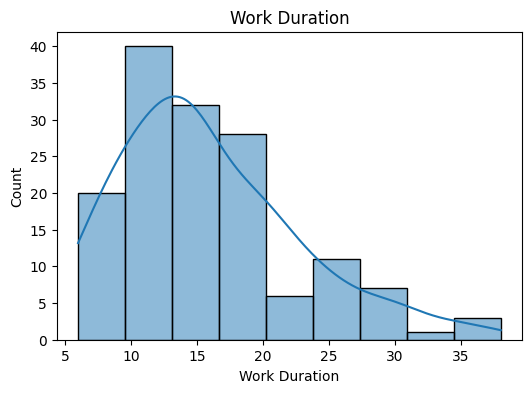

<Figure size 640x480 with 0 Axes>

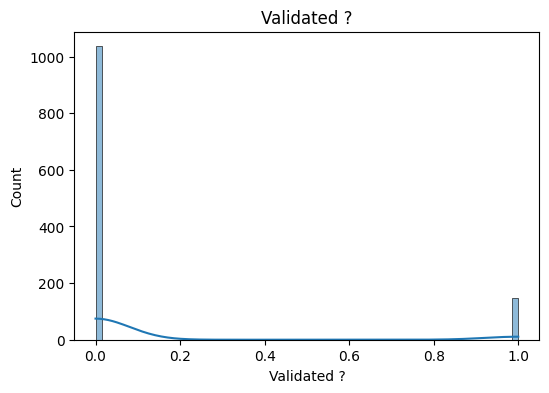

<Figure size 640x480 with 0 Axes>

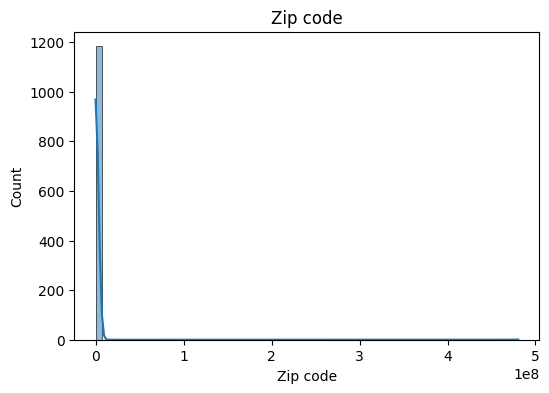

<Figure size 640x480 with 0 Axes>

In [383]:

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot( dataset[col],kde=True)
    plt.title(col)
    plt.show()
    plt.savefig(f'../images/{col}_distribution.png')

outlier detect

In [384]:
print("outliers:")
for col in num_cols:
    Q1 = dataset[col].quantile(.25)
    Q3 = dataset[col].quantile(.75)
    IQR = Q3-Q1
    lower = Q1-1.5*IQR
    upper = Q3+1.5*IQR
    outliers = dataset[(dataset[col]<lower)|(dataset[col]>upper) ]
    print(col,len(outliers))

outliers:
Work Duration 1
Validated ? 148
Zip code 1


In [385]:
correlation_matrix = dataset[num_cols].corr()
correlation_matrix

,Work Duration,Validated ?,Zip code
Work Duration,1.000000,0.080495,0.067208
Validated ?,0.080495,1.000000,-0.010911
Zip code,0.067208,-0.010911,1.000000


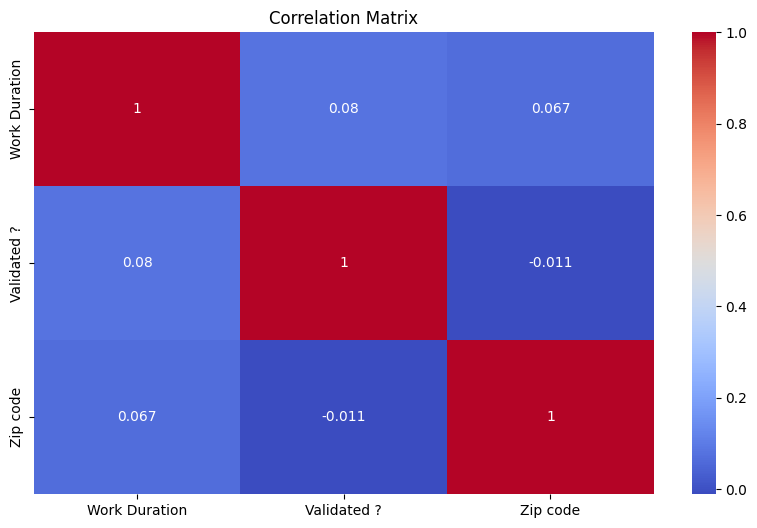

<Figure size 640x480 with 0 Axes>

In [386]:
plt.figure(figsize=(10,6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Matrix")
plt.show()
plt.savefig('../images/correlation_matrix.png')

#### Categorical Analysis

In [387]:
cat_cols = dataset.select_dtypes(
    include='object'
).columns

cat_cols

Index(['Quality Agent Name', 'Assign Date', 'Recording link', 'Validation',
       'Finish Date', 'QA Feedback', 'Validation Date', 'Quality Score %',
       'State', 'DOB', 'City', 'Product', 'Gender', 'Opener Name', 'Client',
       'Opening Status', 'Team Leader', 'Closing Status', 'Closer Name',
       'Date of Sale', 'Comment', 'Creation Date', 'Date of Payment',
       'Pricing List'],
      dtype='object')

In [388]:
print("Categorical Columns and Unique Values:")
for col in cat_cols:
    print(col)
    print(dataset[col].nunique())


Categorical Columns and Unique Values:
Quality Agent Name
6
Assign Date
5
Recording link
51
Validation
3
Finish Date
6
QA Feedback
136
Validation Date
5
Quality Score %
34
State
125
DOB
1046
City
916
Product
2
Gender
2
Opener Name
103
Client
2
Opening Status
5
Team Leader
18
Closing Status
8
Closer Name
13
Date of Sale
39
Comment
884
Creation Date
42
Date of Payment
58
Pricing List
9


In [389]:
for col in cat_cols:
    print( dataset[col].value_counts().head(10))

Quality Agent Name
Dan         45
Lester      45
Robert      34
Jude        26
Victoria    21
Stark       21
Name: count, dtype: int64
Assign Date
29-04-2026    94
28-04-2026    50
30-04-2026    25
1/5/2026      16
4/5/2026       7
Name: count, dtype: int64
Recording link
https://drive.google.com/drive/folders/1QPNPHWn7-Vufjcdhp2UWTKJiS4jQe3nV?usp=drive_link    2
https://drive.google.com/drive/folders/1u3j9mqLJr45d06htv7_DiVDRY6ZBzNqb?usp=drive_link    2
https://drive.google.com/file/d/1f-6ELqGXNGQIugh5I9HSOGtOf8r3One_/view?usp=drive_link      1
https://drive.google.com/drive/folders/1Iaw24v655EFuC8hZaxl__T9Tfeh8OKZ8?usp=drive_link    1
https://drive.google.com/drive/folders/1W1krMJ1_OlQdWGXEJIW0WqHRtDcxXlya?usp=drive_link    1
https://drive.google.com/drive/folders/1Qc_ZT1hl4zhn1sCIKWUnVj9YxGTNs3be?usp=drive_link    1
https://drive.google.com/drive/folders/1HJ1DnJIOpBc_CpG2XGoYQkZd38w34Y_b?usp=drive_link    1
https://drive.google.com/drive/folders/1xC8ldWU5pbhPBBs4oHB6_KjzGPyYYrfu?usp

#### Date columns 

In [390]:
date_cols = [
    'Assign Date',
    'Finish Date',
    'Validation Date',
    'Date of Sale',
    'Creation Date',
    'Date of Payment',
    'DOB'
]

In [391]:
for col in date_cols:
    dataset[col] = pd.to_datetime(dataset[col],  errors='coerce')

In [392]:
for col in date_cols:
    print(col)
    print(dataset[col].min())
    print(dataset[col].max())
    print()

Assign Date
2026-04-28 00:00:00
2026-04-30 00:00:00

Finish Date
2026-01-05 00:00:00
2026-04-05 00:00:00

Validation Date
2026-04-28 00:00:00
2026-04-30 00:00:00

Date of Sale
2026-04-13 00:00:00
2026-05-22 00:00:00

Creation Date
2026-04-13 00:00:00
2026-05-22 00:00:00

Date of Payment
2026-04-13 00:00:00
2026-06-27 00:00:00

DOB
1926-12-03 00:00:00
2026-12-05 00:00:00



In [393]:
(
dataset['Creation Date'].max()
-
dataset['Creation Date'].min()
).days

39

#### process check rate and status

validator status 

In [394]:
dataset["Validated ?"].value_counts()

Validated ?
0    1036
1     148
Name: count, dtype: int64

In [395]:
print(dataset["Validated ?"].mean()*100)

12.5


closing & opening status

In [396]:
dataset["Closing Status"].value_counts()

Closing Status
Approved                 387
Not interested           225
Follow up                172
Cancelled                 95
Not Eligible              94
Retreansfer to client     47
Pending Bank Approval     37
Postdated                 28
Name: count, dtype: int64

In [397]:
dataset["Opening Status"].value_counts()

Opening Status
Transferred       977
Red Flag          102
Call Back          86
Not Eligible       14
Not interested      4
Name: count, dtype: int64

Quality score status

In [398]:
print((
    dataset['Quality Score %'].notna().mean()*100
))

12.837837837837837


#### report data quality 

In [399]:
quality_report = pd.DataFrame({

    "Column":dataset.columns,

    "Missing %":
    round(
        dataset.isnull()
        .mean()*100,
        2
    ),

    "Unique Values":
    dataset.nunique(),

    "Data Type":
    dataset.dtypes

})

quality_report

,Column,Missing %,Unique Values,Data Type
Quality Agent Name,Quality Agent Name,83.78,6,object
Assign Date,Assign Date,85.73,3,datetime64[ns]
Work Duration,Work Duration,87.50,27,float64
Recording link,Recording link,95.52,51,object
Validation,Validation,87.42,3,object
Finish Date,Finish Date,97.97,2,datetime64[ns]
QA Feedback,QA Feedback,87.33,136,object
Validated ?,Validated ?,0.00,2,int64
Validation Date,Validation Date,89.36,3,datetime64[ns]
Quality Score %,Quality Score %,87.16,34,object


### Cleaning Actions
 after review all the dataset columns and rows and cat,num,date columns types i well make this actions:
- let the missing values for QA columns as it not bad data it be the QA Agent not yet reviewed 
- fill customer column with "Unknown" to be not null value
- fill city column with "Unknown" to be not null value  
- fill Gender column with "Unknown" to be not null value
- fill Quality Agent Name with "Not Assigned" to be not null 
- sales columns: closing status fill with "Not closed" if still active, closer name fill with "Not Assigned"  
-  Date of sales mean there are not a sale for now then not fill them 
-  date of payment means not be pay for now then not fill them 
-  Pricing list fill them with "NAN" there are no sale and extract from it a price in new column 
-  convert all date columns to be the same format and type 
-  for quality score make a map to date and convert them 
-  comments column make a new column from extracting with paid today
-  convert zip code to be cat column this is not a numbers this is a unique ID 
-  Remove the one duplicated rwo it to be the same payment and same product and same date then it not new one for the product and customer 

#### Copy new data frame to be cleaning version

In [400]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1184 entries, 0 to 1183
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Quality Agent Name  192 non-null    object        
 1   Assign Date         169 non-null    datetime64[ns]
 2   Work Duration       148 non-null    float64       
 3   Recording link      53 non-null     object        
 4   Validation          149 non-null    object        
 5   Finish Date         24 non-null     datetime64[ns]
 6   QA Feedback         150 non-null    object        
 7   Validated ?         1184 non-null   int64         
 8   Validation Date     126 non-null    datetime64[ns]
 9   Quality Score %     152 non-null    object        
 10  State               1154 non-null   object        
 11  Zip code            1184 non-null   int64         
 12  DOB                 519 non-null    datetime64[ns]
 13  City                1148 non-null   object      

In [401]:
df = dataset.copy()

In [402]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1184 entries, 0 to 1183
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Quality Agent Name  192 non-null    object        
 1   Assign Date         169 non-null    datetime64[ns]
 2   Work Duration       148 non-null    float64       
 3   Recording link      53 non-null     object        
 4   Validation          149 non-null    object        
 5   Finish Date         24 non-null     datetime64[ns]
 6   QA Feedback         150 non-null    object        
 7   Validated ?         1184 non-null   int64         
 8   Validation Date     126 non-null    datetime64[ns]
 9   Quality Score %     152 non-null    object        
 10  State               1154 non-null   object        
 11  Zip code            1184 non-null   int64         
 12  DOB                 519 non-null    datetime64[ns]
 13  City                1148 non-null   object      

#### create a red flag for score quality percentage

In [403]:
df['QA Reviewed'] = (
    df['Quality Score %'].notna().astype(int)
)

In [404]:
df.head()

,Quality Agent Name,Assign Date,Work Duration,Recording link,Validation,Finish Date,QA Feedback,Validated ?,Validation Date,Quality Score %,...,Opening Status,Team Leader,Closing Status,Closer Name,Date of Sale,Comment,Creation Date,Date of Payment,Pricing List,QA Reviewed
0,Jude,2026-04-28,NaN,NaN,NaN,NaT,NaN,0,NaT,NaN,...,Transferred,Kylie Lopez,Approved,Summer Hudson,2026-04-21,PT Paid today,2026-04-21,2026-04-21,NaN,0
1,NaN,NaT,NaN,NaN,NaN,NaT,NaN,0,NaT,NaN,...,Transferred,Timothy Williams,Approved,Summer Hudson,2026-04-22,Pt will pay on 05/03/2026\n\nPayment sent to t...,2026-04-22,2026-05-15,NaN,0
2,NaN,NaT,NaN,NaN,NaN,NaT,NaN,0,NaT,NaN,...,Transferred,Tim ford,Approved,Maeve White,2026-04-21,PT Paid Today,2026-04-23,2026-04-21,NaN,0
3,NaN,NaT,NaN,NaN,NaN,NaT,NaN,0,NaT,NaN,...,Transferred,Kylie Lopez,Approved,Summer Hudson,2026-04-21,PT Paid today,2026-04-23,2026-04-21,NaN,0
4,Victoria,NaT,NaN,NaN,NaN,2026-01-05,NaN,1,NaT,NaN,...,Transferred,Sarah Adams,Approved,Maeve White,2026-04-22,PT Paid Today,2026-04-22,2026-04-22,NaN,0


In [405]:
pd.to_numeric(
    df['Quality Score %'],
    errors='coerce'
)

0      NaN
1      NaN
2      NaN
3      NaN
4      NaN
        ..
1179   NaN
1180   NaN
1181   NaN
1182   NaN
1183   NaN
Name: Quality Score %, Length: 1184, dtype: float64

#### Remove the duplicated row 

In [406]:
df.drop_duplicates(inplace=True)
df.shape

(1183, 28)

#### convert Zip code to categorical

In [407]:
df['Zip code'] = (df['Zip code'].astype(str))

In [408]:
print(df['Zip code'].dtype)

object


#### convert Date columns 

In [409]:
date_cols = [
    'Assign Date',
    'Finish Date',
    'Validation Date',
    'Date of Sale',
    'Creation Date',
    'Date of Payment',
    'DOB'
]

In [410]:
def parse_mixed_dates(series: pd.Series) -> pd.Series:
    parsed = pd.to_datetime(series, dayfirst=True, errors='coerce')
    fallback = pd.to_datetime(series, dayfirst=False, errors='coerce')
    parsed = parsed.fillna(fallback)
    return parsed


In [411]:
for col in date_cols:
    df[col] = parse_mixed_dates(df[col])

for col in date_cols:
    ok  = df[col].notna().sum()
    tot = len(df)
    print(f"  {col:<22} parsed {ok:4d}/{tot} ({ok/tot*100:.0f}%)")

  Assign Date            parsed  169/1183 (14%)
  Finish Date            parsed   24/1183 (2%)
  Validation Date        parsed  126/1183 (11%)
  Date of Sale           parsed  342/1183 (29%)
  Creation Date          parsed  681/1183 (58%)
  Date of Payment        parsed  264/1183 (22%)
  DOB                    parsed  519/1183 (44%)


#### fill missing values for columns

In [412]:
target_cols_fill = [
    'Client',
    'City',
    'Gender'
]

In [413]:
for col in target_cols_fill:
    df[col]=(df[col].fillna('Unknown').astype(str))


In [414]:
df[target_cols_fill].isnull().sum()

Client    0
City      0
Gender    0
dtype: int64

In [415]:
df['Gender'] = df['Gender'].str.title()

closing state , closer name 

In [416]:
df['Closing_status'] = df['Closing Status'].replace(
    {'Retreansfer to client': 'Retransfer to Client'}
)


In [417]:
df['Closing Status'].value_counts()

Closing Status
Approved                 386
Not interested           225
Follow up                172
Cancelled                 95
Not Eligible              94
Retreansfer to client     47
Pending Bank Approval     37
Postdated                 28
Name: count, dtype: int64

In [418]:
df['Closing Status']=df['Closing Status'].fillna('Not closed') 

In [419]:
df['Closing Status'].value_counts()

Closing Status
Approved                 386
Not interested           225
Follow up                172
Not closed                99
Cancelled                 95
Not Eligible              94
Retreansfer to client     47
Pending Bank Approval     37
Postdated                 28
Name: count, dtype: int64

In [420]:
df['Closer Name'].value_counts()

Closer Name
Summer Hudson      272
Lisa Hanz          256
Lilly Williams     231
Maeve White        191
Linda Anderson      45
Marcelle David      36
Jordan Williams     17
kate carter         11
Rose Silva          11
Cole Simmons         4
Louis Mike           2
Adam Steve           2
Lauren Bailey        1
Name: count, dtype: int64

In [421]:
df['Closer Name']=df['Closer Name'].fillna('Not Assigned')

In [422]:
df['Closer Name'].value_counts()

Closer Name
Summer Hudson      272
Lisa Hanz          256
Lilly Williams     231
Maeve White        191
Not Assigned       104
Linda Anderson      45
Marcelle David      36
Jordan Williams     17
kate carter         11
Rose Silva          11
Cole Simmons         4
Adam Steve           2
Louis Mike           2
Lauren Bailey        1
Name: count, dtype: int64

Pricing list fill with NAN 

In [423]:
df['Pricing List'].value_counts()

Pricing List
$39.95/Month    154
$49.95/Month    100
$44.95/Month     94
$69.95/Month     44
$59.95/Month     24
$29.95/Month     15
$34.95/Month     12
$64.95/Month     11
$54.95/Month      1
Name: count, dtype: int64

In [424]:
df['Pricing List']=df['Pricing List'].fillna('NAN')

In [425]:
df['Pricing List'].value_counts()

Pricing List
NAN             728
$39.95/Month    154
$49.95/Month    100
$44.95/Month     94
$69.95/Month     44
$59.95/Month     24
$29.95/Month     15
$34.95/Month     12
$64.95/Month     11
$54.95/Month      1
Name: count, dtype: int64

Opener name, Team leader fill with Not Assigned

In [426]:
df['Opener Name']=df['Opener Name'].fillna('Not Assigned').astype(str)
df['Team Leader']=df['Team Leader'].fillna('Not Assigned').astype(str)
df['Quality Agent Name']=df['Quality Agent Name'].fillna('Not Assigned').astype(str)

Fill Product with mode

In [427]:
df['Product'] = df['Product'].str.title()


In [428]:
df['Product']=df['Product'].fillna(df['Product'].mode()[0])

Opening Status fill with Not called

In [429]:
df['Opening Status'].value_counts()

Opening Status
Transferred       976
Red Flag          102
Call Back          86
Not Eligible       14
Not interested      4
Name: count, dtype: int64

In [430]:
df['Opening Status']=df['Opening Status'].fillna('Not called')

In [431]:
df['Opening Status'].value_counts()

Opening Status
Transferred       976
Red Flag          102
Call Back          86
Not Eligible       14
Not interested      4
Not called          1
Name: count, dtype: int64

In [432]:
print(df.isnull().sum())

Quality Agent Name       0
Assign Date           1014
Work Duration         1035
Recording link        1130
Validation            1034
Finish Date           1159
QA Feedback           1033
Validated ?              0
Validation Date       1057
Quality Score %       1031
State                   30
Zip code                 0
DOB                    664
City                     0
Product                  0
Gender                   0
Opener Name              0
Client                   0
Opening Status           0
Team Leader              0
Closing Status           0
Closer Name              0
Date of Sale           841
Comment                 37
Creation Date          502
Date of Payment        919
Pricing List             0
QA Reviewed              0
Closing_status          99
dtype: int64


#### Extract price from column pricing list
- Pricing information was transformed from text format into a numerical monthly price feature for analysis.

In [433]:
df['Monthly Price'] = (df['Pricing List'].astype(str).str.extract(r'(\d+\.\d+)'))

In [434]:
df['Monthly Price'] = pd.to_numeric(df['Monthly Price'],errors='coerce')

In [435]:
df['Monthly Price'].describe()

count    455.000000
mean      47.312637
std       10.042329
min       29.950000
25%       39.950000
50%       44.950000
75%       49.950000
max       69.950000
Name: Monthly Price, dtype: float64

#### create new business Feature 

In [436]:
df['QA Reviewed'] = (df['Quality Score %'].notna().astype(int))

In [437]:
df['Sale Made']= (df['Date of Sale'].notna().astype(int))

In [438]:
df['Payment Received'] = ( df['Date of Payment'].notna().astype(int))

In [439]:
df['Days To Payment'] = (df['Date of Payment'] - df['Date of Sale']).dt.days
df.loc[df['Days To Payment'] < 0, 'Days To Payment'] = np.nan 

In [440]:
df['Days To Payment'] = (df['Days To Payment'].clip(lower=0))

In [441]:
df['Is Approved'] = df['Closing Status'].eq('Approved').astype(int)


In [442]:
condition = df['Quality Agent Name'].notna() & (df['Quality Agent Name'] != 'Unknown')

df['Has Qa'] = np.where(condition, 1, 0)

In [443]:

df['sale Week'] = df['Creation Date'].dt.to_period('W').dt.start_time
df['sale Day']  = df['Creation Date'].dt.normalize()

In [500]:
df['sale Day'] = pd.to_datetime(df['sale Day'])

In [501]:
df['sale Week'] = pd.to_datetime(df['sale Week'])

In [530]:
df['Date of Sale'] = pd.to_datetime(df['sale Week'])

In [531]:
print(df['sale Day'].dtype)
print(df['sale Week'].dtype)
print(df['Date of Sale'].dtype)

datetime64[ns]
datetime64[ns]
datetime64[ns]


#### Quality Score cleaning 
- Problem: Excel auto-converted some numeric scores (e.g. "10-Aug" was really 80,
- "10-Oct" was 100) because they matched date patterns.
- Known mapping based on Excel's date-serial logic for these short month strings:

In [444]:
df['Quality Score %'].value_counts()

Quality Score %
90        33
95        23
100       19
85        13
10-Sep     9
10-Oct     6
80         6
10-Aug     6
93         3
10-Jul     3
70         3
75         3
94         2
86         2
73         2
10-Jun     1
40         1
10-May     1
99         1
91         1
97         1
50         1
68         1
51         1
98         1
60         1
84         1
83         1
32         1
43         1
88         1
81         1
78         1
87         1
Name: count, dtype: int64

In [445]:
EXCEL_DATE_SCORE_MAP = {
    '10-Jan': 10, '10-Feb': 20, '10-Mar': 30, '10-Apr': 40,
    '10-May': 50, '10-Jun': 60, '10-Jul': 70, '10-Aug': 80,
    '10-Sep': 90, '10-Oct': 100,
}

def clean_quality_score(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if val in EXCEL_DATE_SCORE_MAP:
        return float(EXCEL_DATE_SCORE_MAP[val])
    try:
        score = float(val.replace('%', ''))
        return score if 0 <= score <= 100 else np.nan
    except ValueError:
        return np.nan

df['Quality Score %'] = df['Quality Score %'].apply(clean_quality_score)
print("Quality Score stats after cleaning:")
print(df['Quality Score %'].describe())

Quality Score stats after cleaning:
count    152.00000
mean      87.50000
std       12.33903
min       32.00000
25%       85.00000
50%       90.00000
75%       95.00000
max      100.00000
Name: Quality Score %, dtype: float64


In [446]:
df['Quality Score %'].value_counts()

Quality Score %
90.0     42
100.0    25
95.0     23
85.0     13
80.0     12
70.0      6
93.0      3
75.0      3
50.0      2
94.0      2
73.0      2
60.0      2
86.0      2
40.0      1
97.0      1
99.0      1
98.0      1
68.0      1
51.0      1
91.0      1
83.0      1
84.0      1
32.0      1
43.0      1
88.0      1
81.0      1
78.0      1
87.0      1
Name: count, dtype: int64

#### Final dataset cleaning

In [447]:
print(df.shape)

df.info()

df.head()

(1183, 37)
<class 'pandas.core.frame.DataFrame'>
Index: 1183 entries, 0 to 1183
Data columns (total 37 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Quality Agent Name  1183 non-null   object        
 1   Assign Date         169 non-null    datetime64[ns]
 2   Work Duration       148 non-null    float64       
 3   Recording link      53 non-null     object        
 4   Validation          149 non-null    object        
 5   Finish Date         24 non-null     datetime64[ns]
 6   QA Feedback         150 non-null    object        
 7   Validated ?         1183 non-null   int64         
 8   Validation Date     126 non-null    datetime64[ns]
 9   Quality Score %     152 non-null    float64       
 10  State               1153 non-null   object        
 11  Zip code            1183 non-null   object        
 12  DOB                 519 non-null    datetime64[ns]
 13  City                1183 non-null   object

,Quality Agent Name,Assign Date,Work Duration,Recording link,Validation,Finish Date,QA Feedback,Validated ?,Validation Date,Quality Score %,...,QA Reviewed,Closing_status,Monthly Price,Sale Made,Payment Received,Days To Payment,Is Approved,Has Qa,sale Week,sale Day
0,Jude,2026-04-28,NaN,NaN,NaN,NaT,NaN,0,NaT,NaN,...,0,Approved,NaN,1,1,0.0,1,1,2026-04-20,2026-04-21
1,Not Assigned,NaT,NaN,NaN,NaN,NaT,NaN,0,NaT,NaN,...,0,Approved,NaN,1,1,23.0,1,1,2026-04-20,2026-04-22
2,Not Assigned,NaT,NaN,NaN,NaN,NaT,NaN,0,NaT,NaN,...,0,Approved,NaN,1,1,0.0,1,1,2026-04-20,2026-04-23
3,Not Assigned,NaT,NaN,NaN,NaN,NaT,NaN,0,NaT,NaN,...,0,Approved,NaN,1,1,0.0,1,1,2026-04-20,2026-04-23
4,Victoria,NaT,NaN,NaN,NaN,2026-01-05,NaN,1,NaT,NaN,...,0,Approved,NaN,1,1,0.0,1,1,2026-04-20,2026-04-22


In [448]:
quality_report = pd.DataFrame({

    'Data Type': df.dtypes,

    'Missing Values': df.isnull().sum(),

    'Missing %':
    round(
        df.isnull().mean()*100,
        2
    ),

    'Unique Values':
    df.nunique()

})

quality_report.sort_values(
    'Missing %',
    ascending=False
)

,Data Type,Missing Values,Missing %,Unique Values
Finish Date,datetime64[ns],1159,97.97,2
Recording link,object,1130,95.52,51
Validation Date,datetime64[ns],1057,89.35,3
Work Duration,float64,1035,87.49,27
Validation,object,1034,87.40,3
QA Feedback,object,1033,87.32,136
Quality Score %,float64,1031,87.15,28
Assign Date,datetime64[ns],1014,85.71,3
Days To Payment,float64,944,79.80,19
Date of Payment,datetime64[ns],919,77.68,33


#### Save the clean data 

In [ ]:
df.to_csv('../data/data_cleaned.csv', index=False, encoding='utf-8-sig')

#

---
This dataset appears to represent a lead management and sales funnel process for a healthcare related marketing campaign. Leads are initially created and assigned to sales representatives (Openers), potentially transferred to Closers for final conversion, then reviewed by the Quality Assurance team. The analysis will focus on understanding sales performance, conversion behavior, quality assurance outcomes, and operational efficiency across agents and teams.

--- 
Lead Creation                                                                   
      ↓                                                                                         
Lead Assignment                                                             
      ↓                                                                                 
Sales Activity                                                      
      ↓                                                                             
Quality Assurance Review                                                                        
      ↓                                                                             
Validation                                              
      ↓                                                                     
Sale Closure                                                                                    
      ↓                                                                             
Payment Collection                                                  


# **Phase 2**: Exploratory Data Analysis & Visualization

### Import libraries can use in this phase and make new assigned for data frame

In [ ]:
df=pd.read_csv('../data/data_cleaned.csv')
df.head()

,Quality Agent Name,Assign Date,Work Duration,Recording link,Validation,Finish Date,QA Feedback,Validated ?,Validation Date,Quality Score %,...,QA Reviewed,Closing_status,Monthly Price,Sale Made,Payment Received,Days To Payment,Is Approved,Has Qa,sale Week,sale Day
0,Jude,2026-04-28,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,...,0,Approved,NaN,1,1,0.0,1,1,2026-04-20,2026-04-21
1,Not Assigned,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,...,0,Approved,NaN,1,1,23.0,1,1,2026-04-20,2026-04-22
2,Not Assigned,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,...,0,Approved,NaN,1,1,0.0,1,1,2026-04-20,2026-04-23
3,Not Assigned,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,...,0,Approved,NaN,1,1,0.0,1,1,2026-04-20,2026-04-23
4,Victoria,NaN,NaN,NaN,NaN,2026-01-05,NaN,1,NaN,NaN,...,0,Approved,NaN,1,1,0.0,1,1,2026-04-20,2026-04-22


### Analysis Columns 

#### KPI cards

In [451]:
total_leads    = len(df)
total_approved = df['Is Approved'].sum()
approval_rate  = total_approved / total_leads * 100
total_revenue  = (df[df['Is Approved']==1]['Monthly Price'].sum())
avg_qs         = df['Quality Score %'].mean()
median_ttp     = df['Days To Payment'].median()

print(f"  {'KPI':<30} {'Value':>10}")
print(f"  {'Total Leads':<30} {total_leads:>10,}")
print(f"  {'Approved Sales':<30} {total_approved:>10,}")
print(f"  {'Overall Approval Rate':<30} {approval_rate:>9.1f}%")
print(f"  {'Est. Monthly Revenue':<30} ${total_revenue:>9,.2f}")
print(f"  {'Avg Quality Score':<30} {avg_qs:>9.1f}")
print(f"  {'Median Days to Payment':<30} {median_ttp:>10.0f}")


  KPI                                 Value
  Total Leads                         1,183
  Approved Sales                        386
  Overall Approval Rate               32.6%
  Est. Monthly Revenue           $ 7,676.70
  Avg Quality Score                   87.5
  Median Days to Payment                  0


#### How many leads progress through each stage of the funnel?

In [452]:
funnel = pd.DataFrame({
    "Stage":[
        "Total Leads",
        "Assigned QA",
        "Validated",
        "Sale Made",
        "Payment Received"
    ],
    "Count":[
        len(df),
        df['QA Reviewed'].sum(),
        df['Validated ?'].sum(),
        df['Sale Made'].sum(),
        df['Payment Received'].sum()
    ]
})

funnel

,Stage,Count
0,Total Leads,1183
1,Assigned QA,152
2,Validated,148
3,Sale Made,342
4,Payment Received,264


In [495]:
fig = px.funnel(funnel,x='Count',y='Stage',title='Sales Funnel Analysis')
fig.show()

#### QA Review Analysis
Business Question:
   - Does QA review affect sales performance?

In [455]:
print((df['QA Reviewed'].mean()*100))


12.848689771766693


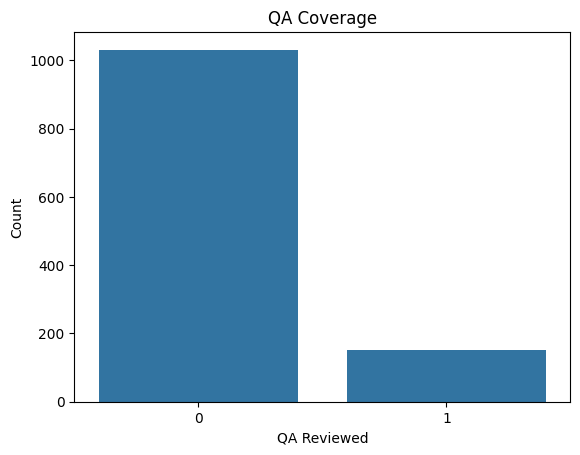

<Figure size 640x480 with 0 Axes>

In [456]:
sns.countplot(
    data=df,
    x='QA Reviewed'
)

plt.title(
    "QA Coverage"
)
plt.xlabel("QA Reviewed")
plt.ylabel("Count")
plt.show()
plt.savefig('../images/qa_coverage.png')

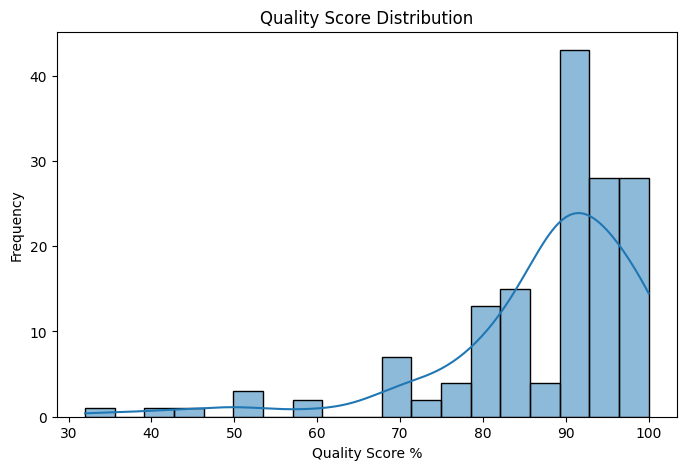

<Figure size 640x480 with 0 Axes>

In [457]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Quality Score %'],
    kde=True
)

plt.title(
    "Quality Score Distribution"
)
plt.xlabel("Quality Score %")
plt.ylabel("Frequency")
plt.show()
plt.savefig('../images/quality_score_distribution.png')

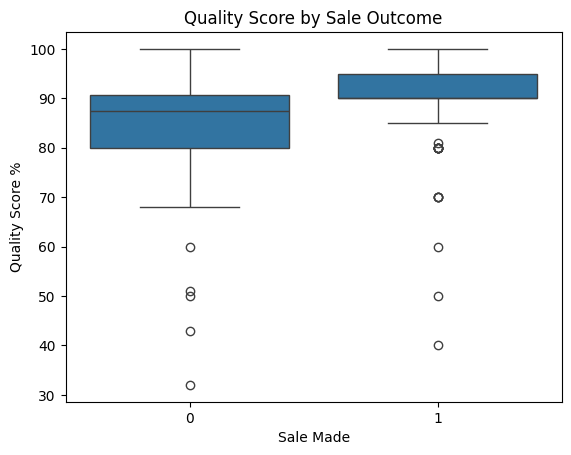

<Figure size 640x480 with 0 Axes>

In [458]:
sns.boxplot(
    data=df,
    x='Sale Made',
    y='Quality Score %'
)
plt.title(
    "Quality Score by Sale Outcome"
)
plt.xlabel("Sale Made")
plt.ylabel("Quality Score %")
plt.show()
plt.savefig('../images/quality_score_by_sale.png')

#### Product Performance Analysis

In [459]:
top_products = (df['Product'].value_counts().head(10))

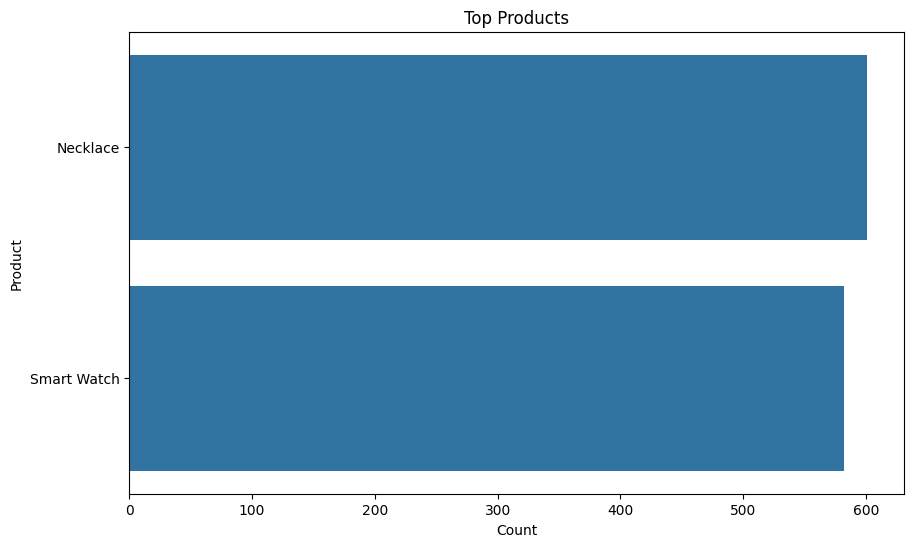

<Figure size 640x480 with 0 Axes>

In [461]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title(
    "Top Products"
)
plt.xlabel("Count")
plt.ylabel("Product")
plt.show()
plt.savefig('../images/top_products.png')

In [462]:
product_sales = (df.groupby('Product')['Sale Made'].mean().sort_values(ascending=False))

In [ ]:
product_sales.head(15)

In [463]:
revenue = (df.groupby('Product')['Monthly Price'].sum())

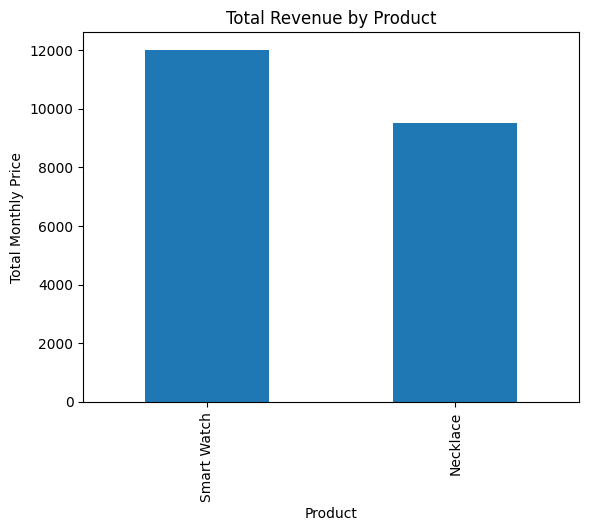

<Figure size 640x480 with 0 Axes>

In [464]:
revenue.sort_values(
    ascending=False
).plot(
    kind='bar'
)
plt.title(
    "Total Revenue by Product"
)
plt.xlabel("Product")
plt.ylabel("Total Monthly Price")
plt.show()
plt.savefig('../images/revenue_by_product.png')

#### Team leader Performance

In [469]:
leader_leads = (df.groupby('Team Leader').size())

In [470]:
leader_sales = (df.groupby('Team Leader')['Sale Made'].sum())

In [471]:
leader_conversion = (df.groupby('Team Leader')['Sale Made'].mean()*100)

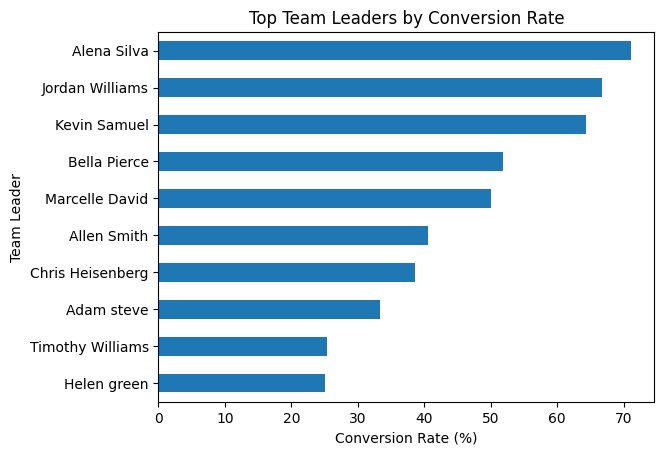

<Figure size 640x480 with 0 Axes>

In [472]:
leader_conversion.sort_values().tail(10).plot(kind='barh')
plt.title("Top Team Leaders by Conversion Rate")
plt.xlabel("Conversion Rate (%)")
plt.ylabel("Team Leader")
plt.show()
plt.savefig('../images/top_team_leaders.png')

#### Closer Performance

In [473]:
closer_sales = (df.groupby('Closer Name')['Sale Made'].sum())

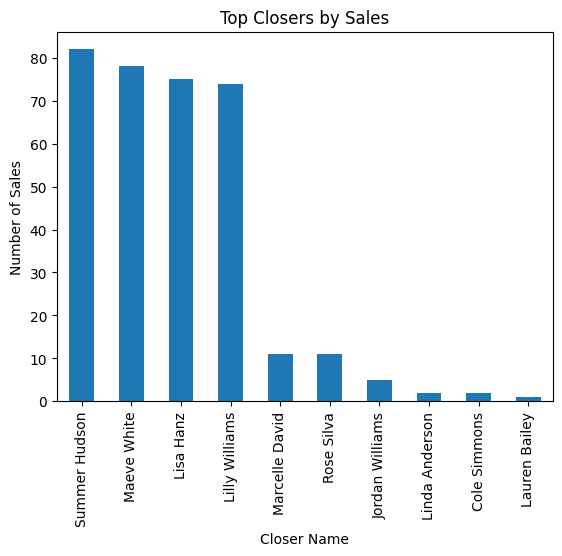

<Figure size 640x480 with 0 Axes>

In [474]:
closer_sales.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Closers by Sales")
plt.xlabel("Closer Name")
plt.ylabel("Number of Sales")
plt.show()
plt.savefig('../images/top_closers.png')

In [475]:
closer_conversion = (df.groupby('Closer Name')['Sale Made'].mean()*100)

In [476]:
top_closers = (df.pivot_table(index='Closer Name',values='Sale Made',aggfunc='mean'))

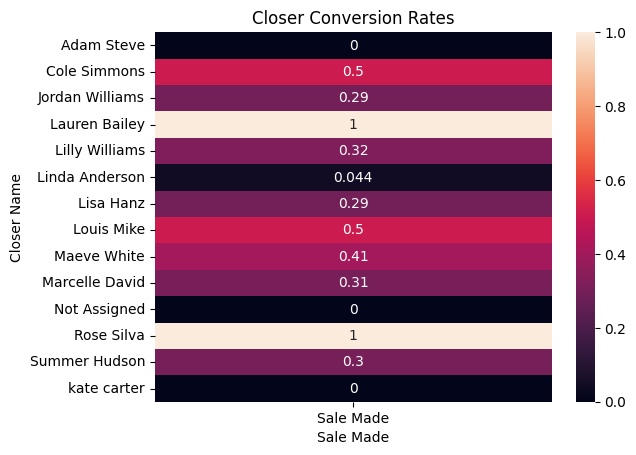

<Figure size 640x480 with 0 Axes>

In [477]:
sns.heatmap(top_closers,annot=True)
plt.title("Closer Conversion Rates")
plt.xlabel("Sale Made")
plt.ylabel("Closer Name")
plt.show()
plt.savefig('../images/closer_conversion_rates.png')


#### State Analysis -Geographical insights

In [478]:
state_counts = (df['State'].value_counts().head(15))

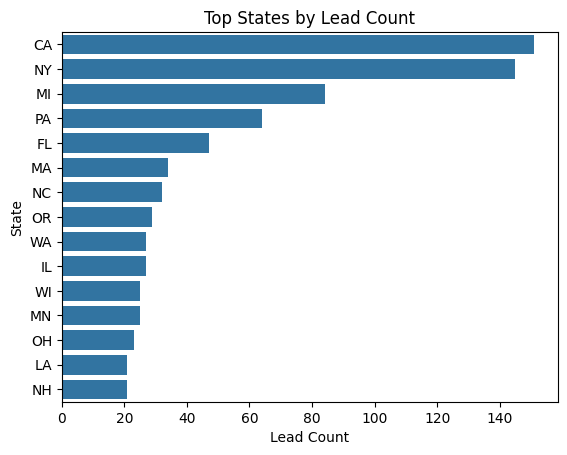

<Figure size 640x480 with 0 Axes>

In [479]:
sns.barplot(x=state_counts.values,y=state_counts.index)
plt.title("Top States by Lead Count")
plt.xlabel("Lead Count")
plt.ylabel("State")
plt.show()
plt.savefig('../images/top_states.png')


In [480]:
state_conversion = (df.groupby('State')['Sale Made'].mean()*100)

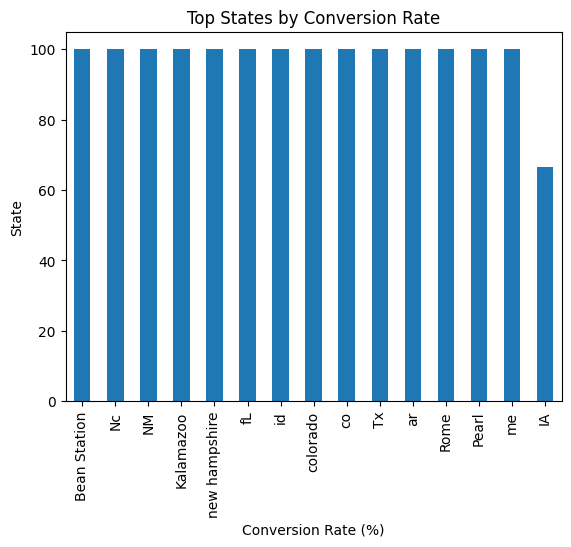

<Figure size 640x480 with 0 Axes>

In [481]:
state_conversion.sort_values(ascending=False).head(15).plot(kind='bar')
plt.title("Top States by Conversion Rate")
plt.xlabel("Conversion Rate (%)")
plt.ylabel("State")
plt.show()
plt.savefig('../images/top_states_conversion.png')

#### Payment Analysis

In [482]:
df['Payment Received'].value_counts()

Payment Received
0    919
1    264
Name: count, dtype: int64

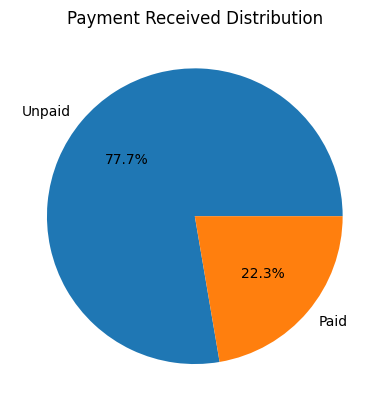

<Figure size 640x480 with 0 Axes>

In [483]:
plt.pie(df['Payment Received' ].value_counts(),labels=['Unpaid', 'Paid'],autopct='%1.1f%%')
plt.title("Payment Received Distribution")
plt.show()
plt.savefig('../images/payment_received_distribution.png')


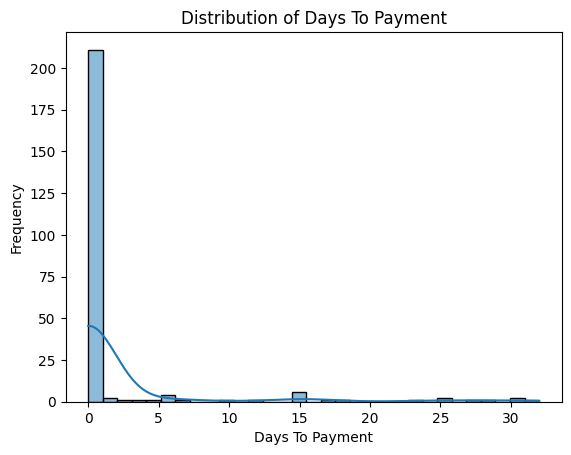

<Figure size 640x480 with 0 Axes>

In [484]:
sns.histplot(df['Days To Payment'],kde=True)
plt.title("Distribution of Days To Payment")
plt.xlabel("Days To Payment")
plt.ylabel("Frequency")
plt.show()
plt.savefig('../images/days_to_payment_distribution.png')

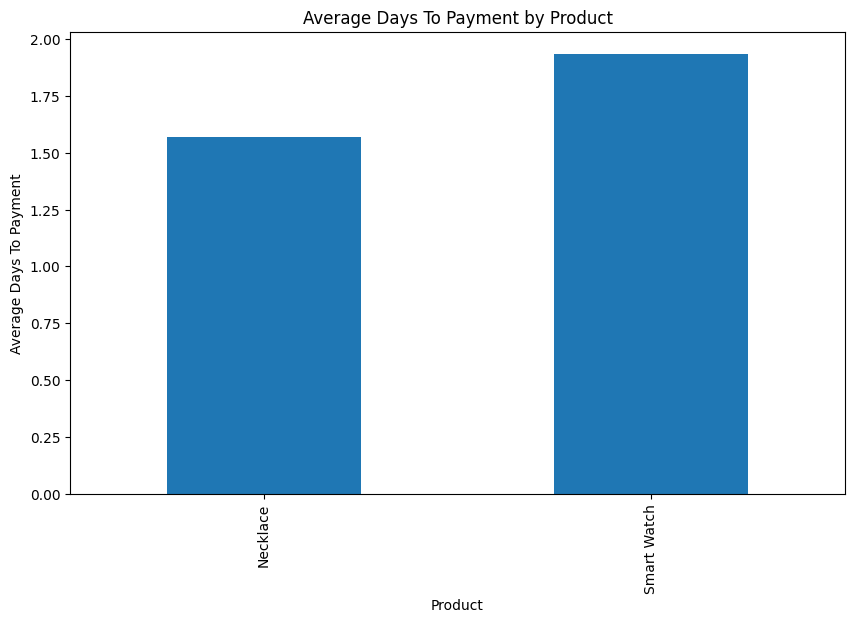

<Figure size 640x480 with 0 Axes>

In [485]:
payment_delay = (df.groupby('Product')['Days To Payment'].mean())
plt.figure(figsize=(10,6))
payment_delay.sort_values().plot(kind='bar')
plt.title("Average Days To Payment by Product")
plt.xlabel("Product")
plt.ylabel("Average Days To Payment")
plt.show()
plt.savefig('../images/average_days_to_payment_by_product.png')

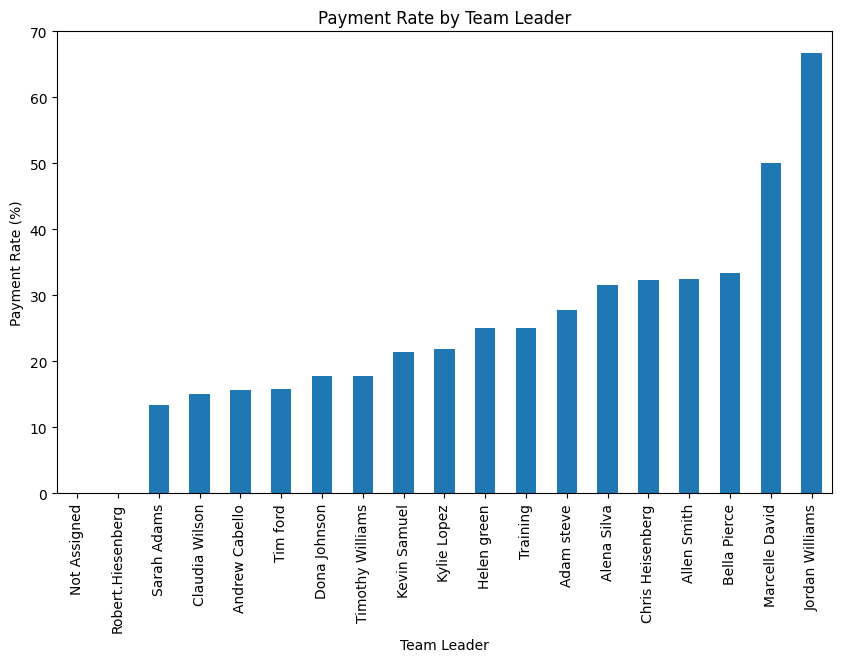

<Figure size 640x480 with 0 Axes>

In [486]:
payment_rate = (df.groupby('Team Leader')['Payment Received'].mean()*100)
plt.figure(figsize=(10,6))
payment_rate.sort_values().plot(kind='bar')
plt.title("Payment Rate by Team Leader")
plt.xlabel("Team Leader")
plt.ylabel("Payment Rate (%)")
plt.show()
plt.savefig('../images/payment_rate_by_team_leader.png')

### **Advanced Analysis and Visualize** 

#### Lead overview

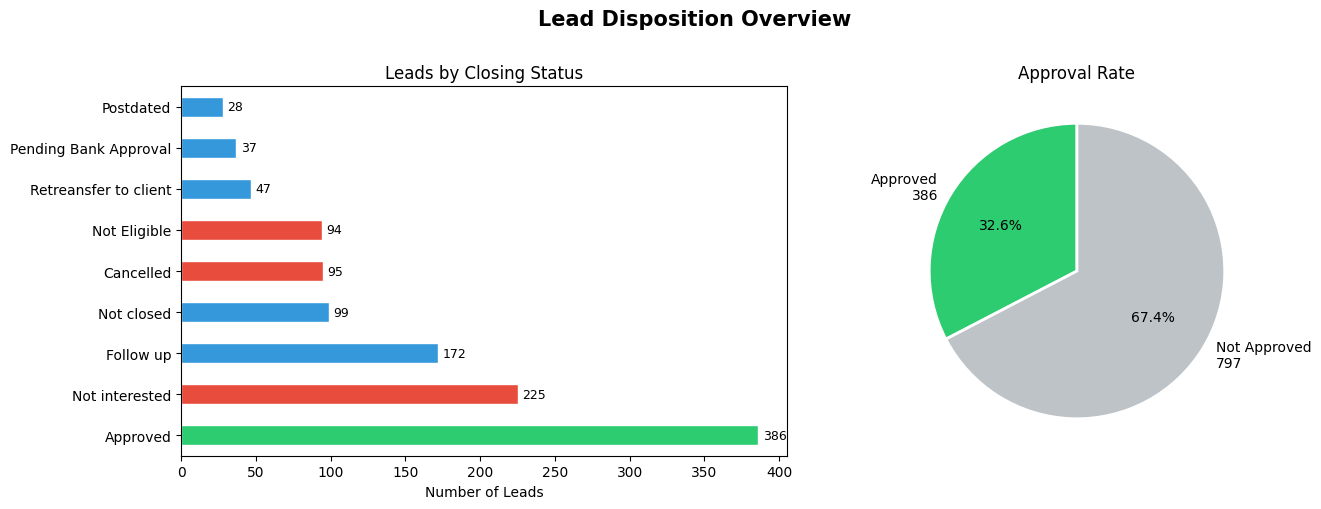

In [487]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Lead Disposition Overview', fontsize=15, fontweight='bold', y=1.01)

# Left: count by status
status_counts = df['Closing Status'].value_counts().dropna()
colors = ['#2ECC71' if s == 'Approved' else '#E74C3C' if s in
          ['Cancelled', 'Not interested', 'Not Eligible'] else '#3498DB'
          for s in status_counts.index]
status_counts.plot(kind='barh', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Leads by Closing Status')
axes[0].set_xlabel('Number of Leads')
axes[0].set_ylabel('')
for bar, val in zip(axes[0].patches, status_counts.values):
    axes[0].text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
                 f'{val}', va='center', fontsize=9)

# Right: pie of approved vs not
pie_data  = [total_approved, total_leads - total_approved]
pie_label = [f'Approved\n{total_approved}', f'Not Approved\n{total_leads-total_approved}']
axes[1].pie(pie_data, labels=pie_label, colors=['#2ECC71','#BDC3C7'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Approval Rate')

plt.tight_layout()
plt.savefig('../images/plot_01_lead_disposition.png', bbox_inches='tight', dpi=150)
plt.show()


#### Agents performance opener and closer

In [488]:
closer_perf = (
    df[df['Closer Name'].notna()]
    .groupby('Closer Name')
    .agg(total=('Is Approved','count'), approved=('Is Approved','sum'))
    .assign(approval_rate=lambda x: x.approved / x.total * 100)
    .query('total >= 10')
    .sort_values('approved', ascending=True)
    .tail(10)
)
opener_perf = (
    df[df['Opener Name'].notna()]
    .groupby('Opener Name')
    .agg(total=('Is Approved','count'), approved=('Is Approved','sum'))
    .assign(conv_rate=lambda x: x.approved / x.total * 100)
    .query('total >= 10')
    .sort_values('conv_rate', ascending=True)
    .tail(10)
)

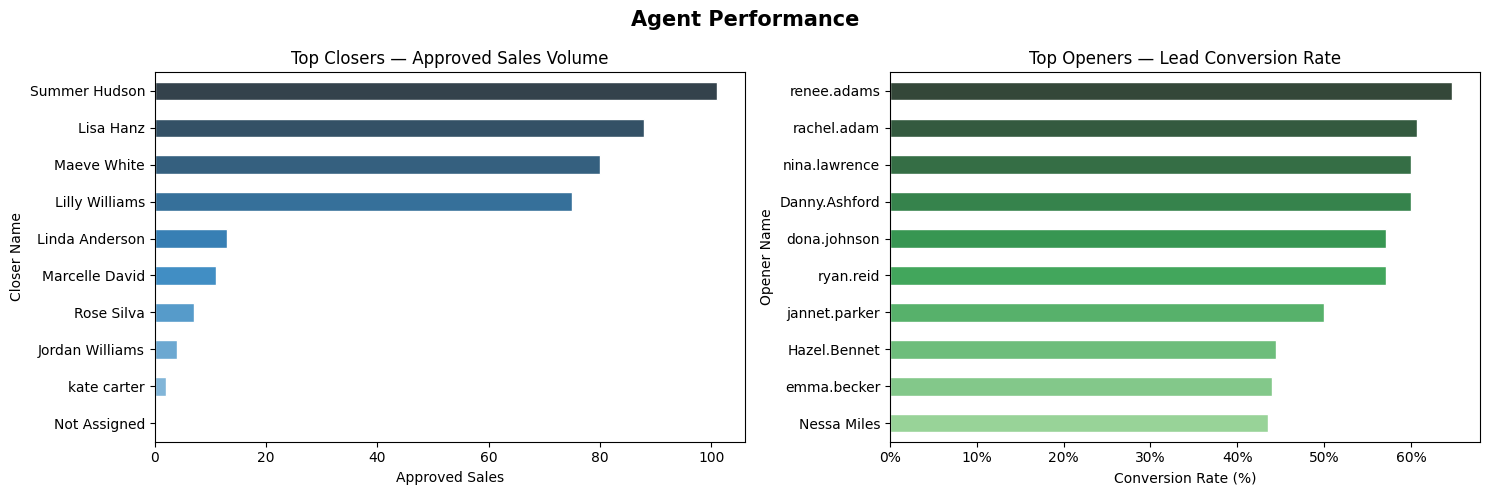

In [489]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Agent Performance', fontsize=15, fontweight='bold')


closer_perf['approved'].plot(kind='barh', ax=axes[0],
                              color=sns.color_palette('Blues_d', len(closer_perf)),
                              edgecolor='white')
axes[0].set_title('Top Closers — Approved Sales Volume')
axes[0].set_xlabel('Approved Sales')
axes[0].set_ylabel('Closer Name')



opener_perf['conv_rate'].plot(kind='barh', ax=axes[1],
                               color=sns.color_palette('Greens_d', len(opener_perf)),
                               edgecolor='white')
axes[1].set_title('Top Openers — Lead Conversion Rate')
axes[1].set_xlabel('Conversion Rate (%)')
axes[1].set_ylabel('Opener Name')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.savefig('../images/plot_02_agent_performance.png', bbox_inches='tight', dpi=150)
plt.show()


#### Product & Pricing Analysis 


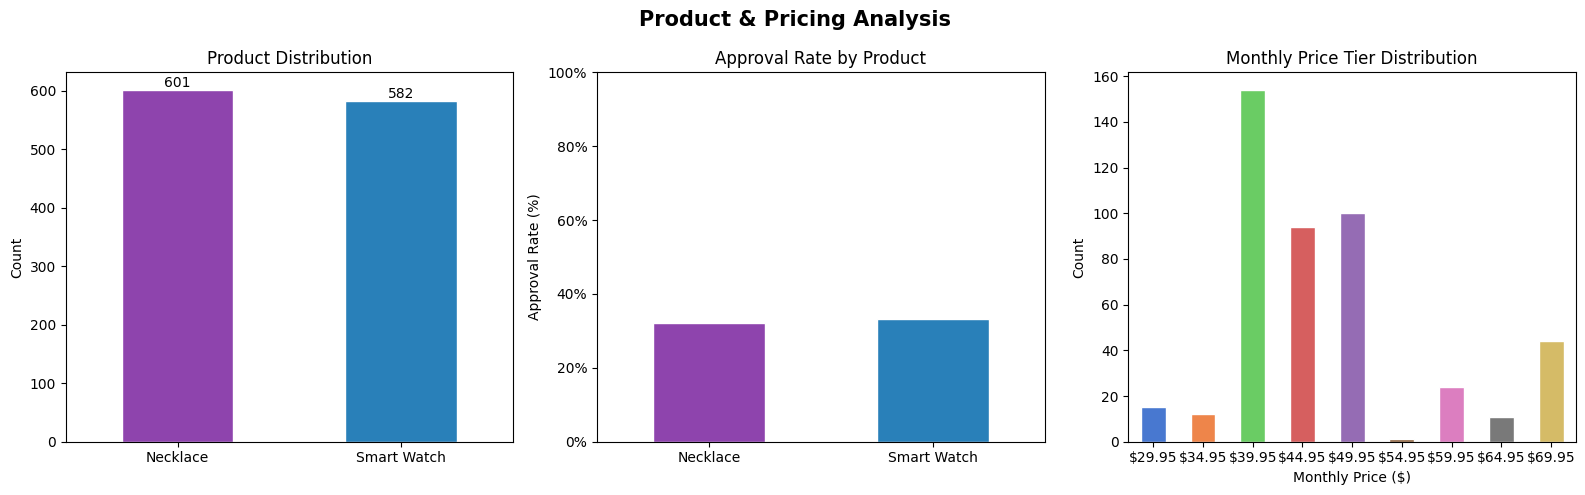

In [490]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Product & Pricing Analysis', fontsize=15, fontweight='bold')

# Product mix
prod_counts = df['Product'].value_counts().dropna()
prod_counts.plot(kind='bar', ax=axes[0],
                 color=['#8E44AD','#2980B9'], edgecolor='white', rot=0)
axes[0].set_title('Product Distribution')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.0f}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Product × approval rate
prod_appr = (
    df.dropna(subset=['Product'])
    .groupby('Product')['Is Approved']
    .mean() * 100
)
prod_appr.plot(kind='bar', ax=axes[1],
               color=['#8E44AD','#2980B9'], edgecolor='white', rot=0)
axes[1].set_title('Approval Rate by Product')
axes[1].set_xlabel('')
axes[1].set_ylabel('Approval Rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_ylim(0, 100)

# Price-tier distribution
price_counts = df['Monthly Price'].value_counts().sort_index()
price_counts.plot(kind='bar', ax=axes[2],
                  color=sns.color_palette('muted'), edgecolor='white', rot=0)
axes[2].set_title('Monthly Price Tier Distribution')
axes[2].set_xlabel('Monthly Price ($)')
axes[2].set_ylabel('Count')
axes[2].set_xticklabels([f'${p:.2f}' for p in price_counts.index])

plt.tight_layout()
plt.savefig('../images/plot_03_product_pricing.png', bbox_inches='tight', dpi=150)
plt.show()

#### Quality Score Distribution 


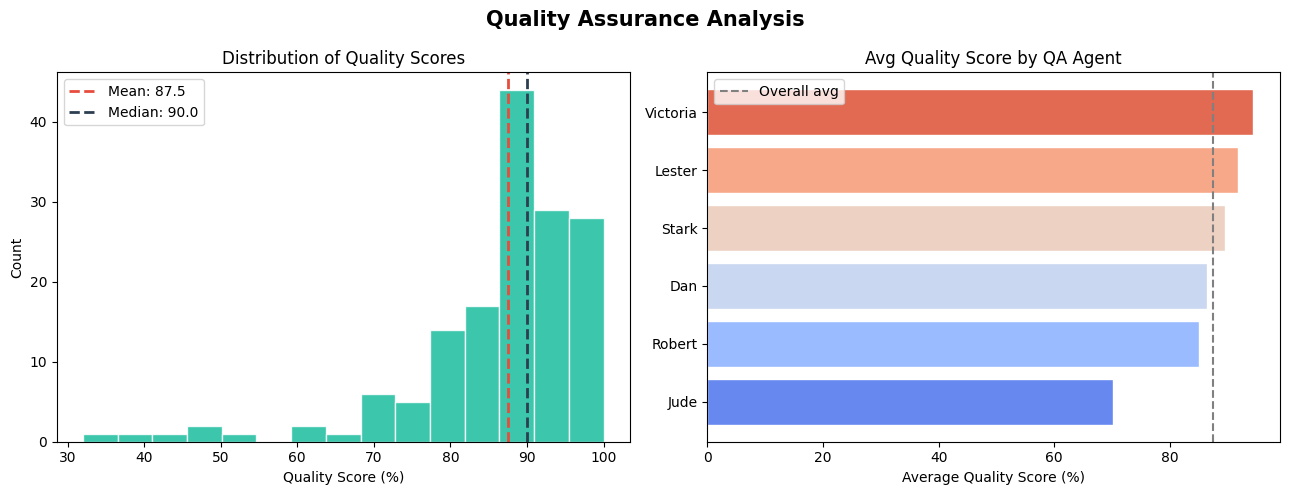

In [491]:
qa_df = df[df['Quality Score %'].notna()]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Quality Assurance Analysis', fontsize=15, fontweight='bold')

# Distribution of QA scores
axes[0].hist(qa_df['Quality Score %'], bins=15, color='#1ABC9C',
             edgecolor='white', alpha=0.85)
axes[0].axvline(qa_df['Quality Score %'].mean(),
                color='#E74C3C', linestyle='--', lw=2,
                label=f"Mean: {qa_df['Quality Score %'].mean():.1f}")
axes[0].axvline(qa_df['Quality Score %'].median(),
                color='#2C3E50', linestyle='--', lw=2,
                label=f"Median: {qa_df['Quality Score %'].median():.1f}")
axes[0].set_title('Distribution of Quality Scores')
axes[0].set_xlabel('Quality Score (%)')
axes[0].set_ylabel('Count')
axes[0].legend()

# QA score by quality agent
qa_by_agent = (
    qa_df.groupby('Quality Agent Name')['Quality Score %']
    .agg(['mean','count'])
    .query('count >= 3')
    .sort_values('mean')
)
axes[1].barh(qa_by_agent.index, qa_by_agent['mean'],
             color=sns.color_palette('coolwarm', len(qa_by_agent)),
             edgecolor='white')
axes[1].set_title('Avg Quality Score by QA Agent')
axes[1].set_xlabel('Average Quality Score (%)')
axes[1].set_ylabel('')
axes[1].axvline(qa_df['Quality Score %'].mean(),
                color='grey', linestyle='--', lw=1.5, label='Overall avg')
axes[1].legend()

plt.tight_layout()
plt.savefig('../images/plot_04_quality_scores.png', bbox_inches='tight', dpi=150)
plt.show()


#### Days to Payment & Team Leader Performance 

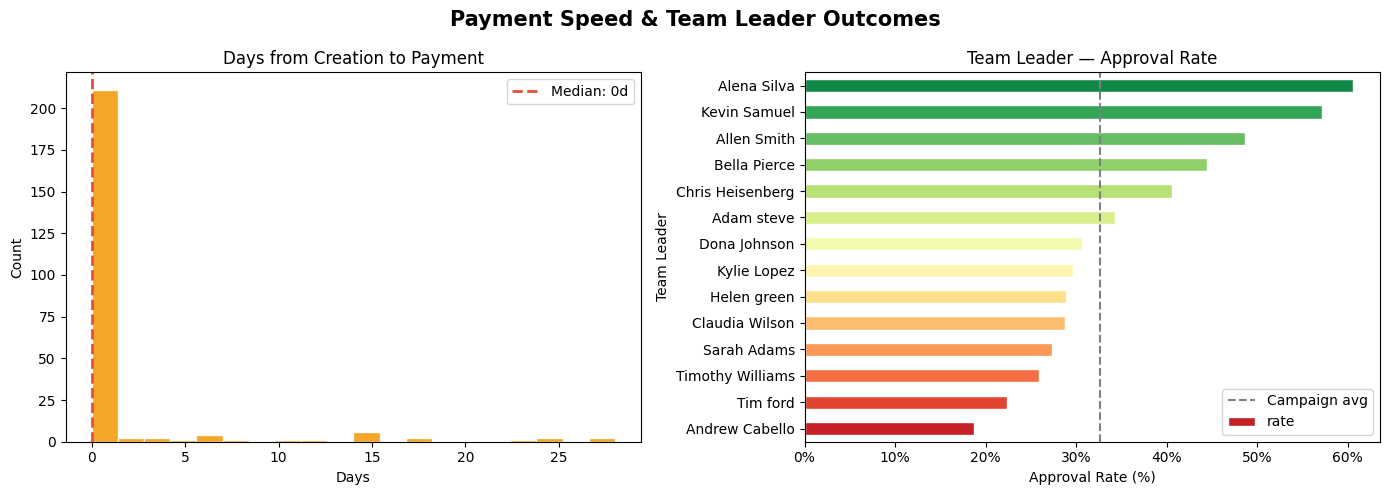

In [492]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Payment Speed & Team Leader Outcomes', fontsize=15, fontweight='bold')

# Days to payment boxplot
ttp = df['Days To Payment'].dropna()
ttp = ttp[ttp <= ttp.quantile(0.99)]  # trim extreme outliers
axes[0].hist(ttp, bins=20, color='#F39C12', edgecolor='white', alpha=0.9)
axes[0].axvline(ttp.median(), color='#E74C3C', linestyle='--', lw=2,
                label=f'Median: {ttp.median():.0f}d')
axes[0].set_title('Days from Creation to Payment')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Count')
axes[0].legend()

# Team leader approval rates
tl_perf = (
    df[df['Team Leader'].notna()]
    .groupby('Team Leader')
    .agg(total=('Is Approved','count'), approved=('Is Approved','sum'))
    .assign(rate=lambda x: x.approved / x.total * 100)
    .query('total >= 10')
    .sort_values('rate', ascending=True)
)
tl_perf['rate'].plot(kind='barh', ax=axes[1],
                     color=sns.color_palette('RdYlGn', len(tl_perf)),
                     edgecolor='white')
axes[1].set_title('Team Leader — Approval Rate')
axes[1].set_xlabel('Approval Rate (%)')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].axvline(df['Is Approved'].mean()*100, color='grey',
                linestyle='--', lw=1.5, label='Campaign avg')
axes[1].legend()

plt.tight_layout()
plt.savefig('../images/plot_05_payment_team.png', bbox_inches='tight', dpi=150)
plt.show()


#### Gender & State demographics


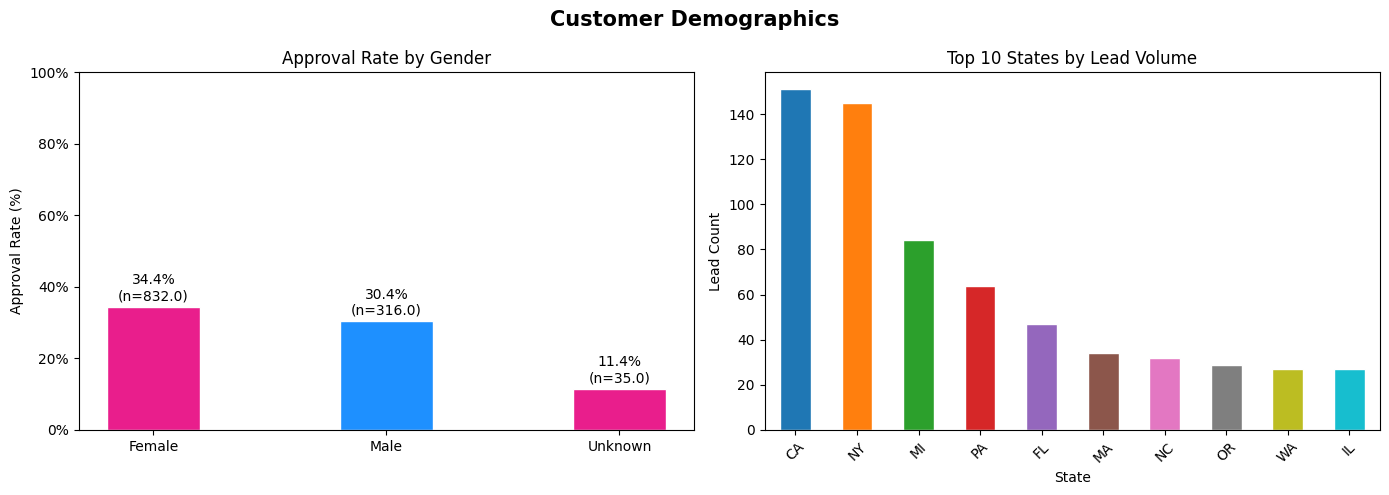

In [493]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Customer Demographics', fontsize=15, fontweight='bold')

# Gender split
gender_appr = (
    df.dropna(subset=['Gender'])
    .groupby('Gender')['Is Approved']
    .agg(['mean','count'])
    .rename(columns={'mean':'approval_rate','count':'leads'})
)
axes[0].bar(gender_appr.index, gender_appr['approval_rate']*100,
            color=['#E91E8C','#1E90FF'], edgecolor='white', width=0.4)
axes[0].set_title('Approval Rate by Gender')
axes[0].set_ylabel('Approval Rate (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_ylim(0, 100)
for i, (gender, row) in enumerate(gender_appr.iterrows()):
    axes[0].text(i, row['approval_rate']*100 + 1,
                 f"{row['approval_rate']*100:.1f}%\n(n={row['leads']:,})",
                 ha='center', va='bottom', fontsize=10)

# Top 10 states by lead volume
top_states = df['State'].value_counts().head(10)
top_states.plot(kind='bar', ax=axes[1],
                color=sns.color_palette('tab10'), edgecolor='white', rot=45)
axes[1].set_title('Top 10 States by Lead Volume')
axes[1].set_xlabel('State')
axes[1].set_ylabel('Lead Count')

plt.tight_layout()
plt.savefig('../images/plot_06_demographics.png', bbox_inches='tight', dpi=150)
plt.show()


# **Phase 3**: Time-Series Analysis & Forecasting
- aggregate daily lead creation counts and approved sales to model the campaign trajectory. Given the relatively short date range (6 weeks)
- Prophet is preferred here because it natively handles weekly seasonality and missing dates without requiring a complete, evenly spaced time series both common issues in campaign data.     
---
Keys:
1. Are sales increasing or decreasing over time?
2. Are payments following a similar trend?
3. Are there seasonal patterns within the campaign?
4. What can we expect in future sales performance?

#### Daily Sales Dataset

In [519]:
sales_ts = (df.dropna(subset=['Date of Sale']).groupby('Date of Sale').size().reset_index(name='Sales'))

sales_ts.head()

,Date of Sale,Sales
0,2026-04-13,17
1,2026-04-14,9
2,2026-04-15,17
3,2026-04-16,9
4,2026-04-17,22


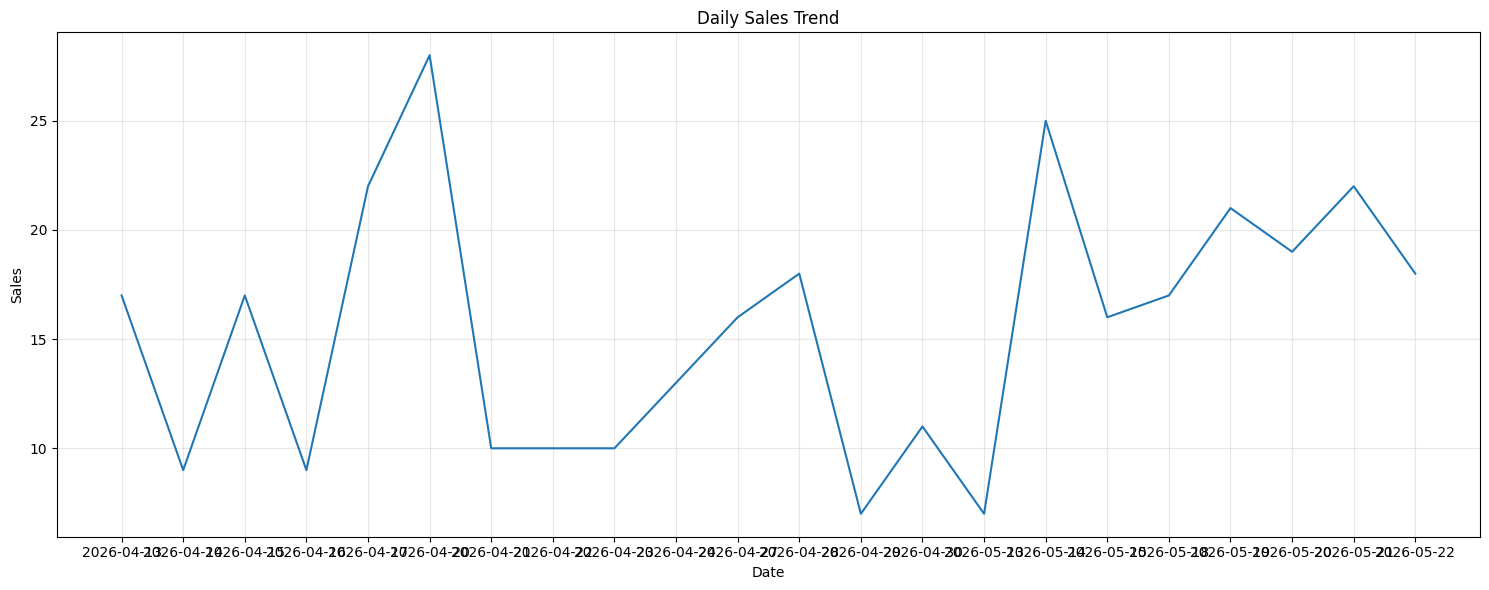

In [520]:
plt.figure(figsize=(15,6))

plt.plot(sales_ts['Date of Sale'],sales_ts['Sales'])
plt.title( 'Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../images/daily_sales_trend.png', bbox_inches='tight', dpi=150)
plt.show()

#### Rolling Average

In [525]:
sales_ts['7D_MA'] = ( sales_ts['Sales'].rolling(7).mean())

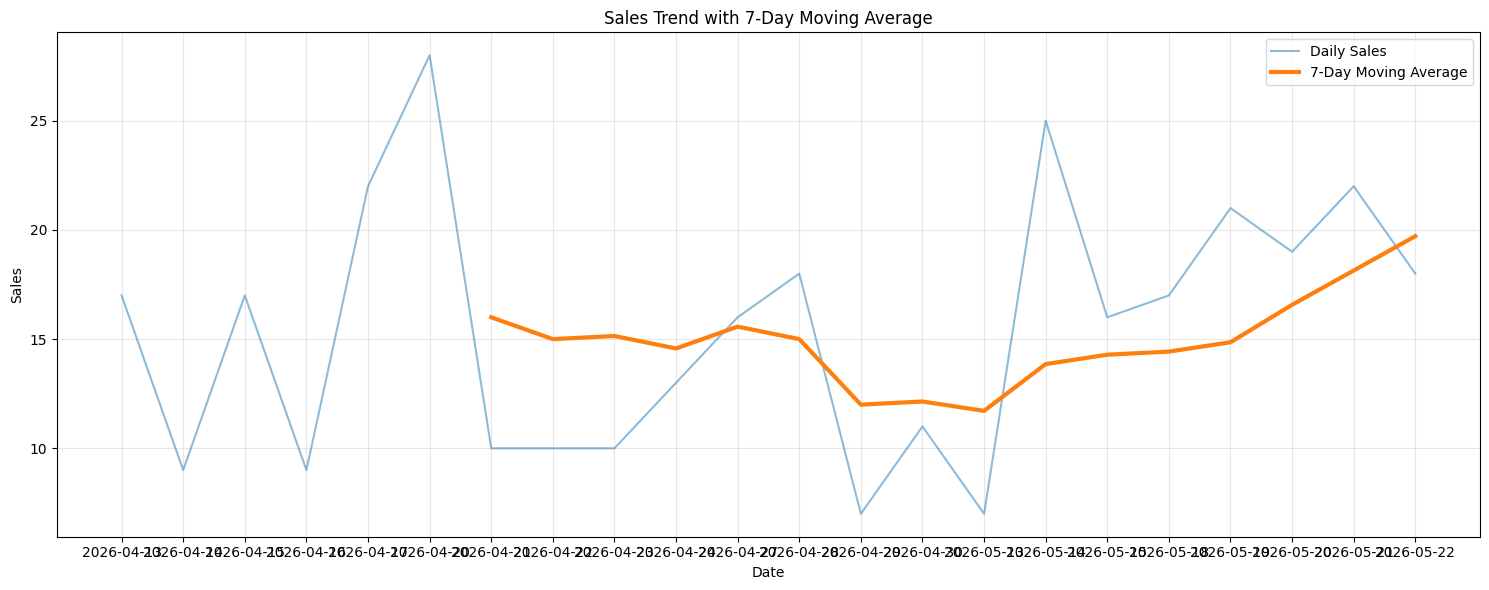

In [526]:
plt.figure(figsize=(15,6))

plt.plot(sales_ts['Date of Sale'],sales_ts['Sales'],label='Daily Sales', alpha=0.5)
plt.plot(sales_ts['Date of Sale'],sales_ts['7D_MA'],linewidth=3,label='7-Day Moving Average')
plt.legend()
plt.title('Sales Trend with 7-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../images/sales_trend_ma.png', bbox_inches='tight', dpi=150)
plt.show()

#### Weekly Sales Trend

In [534]:
print(sales_ts['Date of Sale'].dtype)

object


In [535]:
sales_ts['Date of Sale'] = pd.to_datetime(
    sales_ts['Date of Sale'],
    dayfirst=True,
    errors='coerce'
)

In [537]:
weekly_sales = (sales_ts.set_index('Date of Sale').resample('W').sum())
weekly_sales.head()

,Sales,7D_MA
Date of Sale,,
2026-04-19,74,0.000000
2026-04-26,71,60.714286
2026-05-03,52,54.714286
2026-05-10,0,0.000000
2026-05-17,48,39.857143


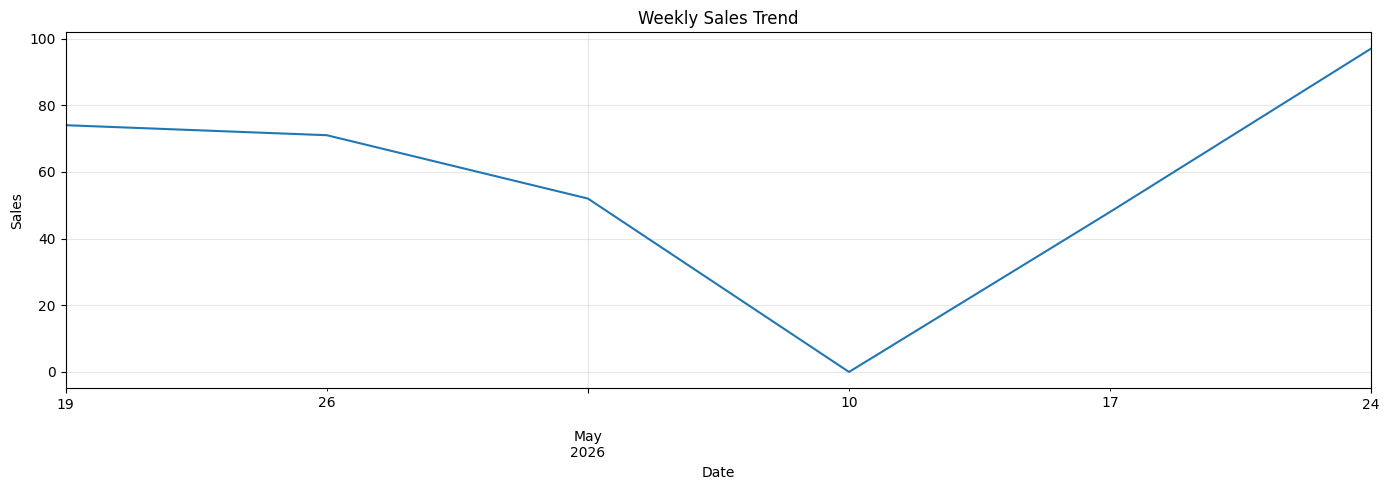

In [538]:
plt.figure(figsize=(14,5))

weekly_sales['Sales'].plot()

plt.title('Weekly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../images/weekly_sales_trend.png', bbox_inches='tight', dpi=150)
plt.show()

#### Day of Week Analysis

In [539]:
sales_ts['Weekday'] = (sales_ts['Date of Sale'].dt.day_name())

In [540]:
weekday_sales = (sales_ts.groupby('Weekday')['Sales'].mean())

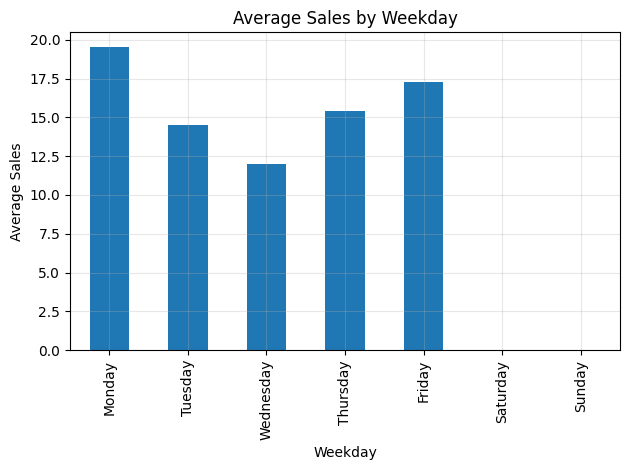

In [541]:
weekday_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

weekday_sales = weekday_sales.reindex(weekday_order)

weekday_sales.plot(kind='bar')

plt.title('Average Sales by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Average Sales')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../images/average_sales_weekday.png', bbox_inches='tight', dpi=150)
plt.show()

#### Monthly Trend

In [542]:
monthly_sales = (sales_ts.set_index('Date of Sale').resample('M').sum())

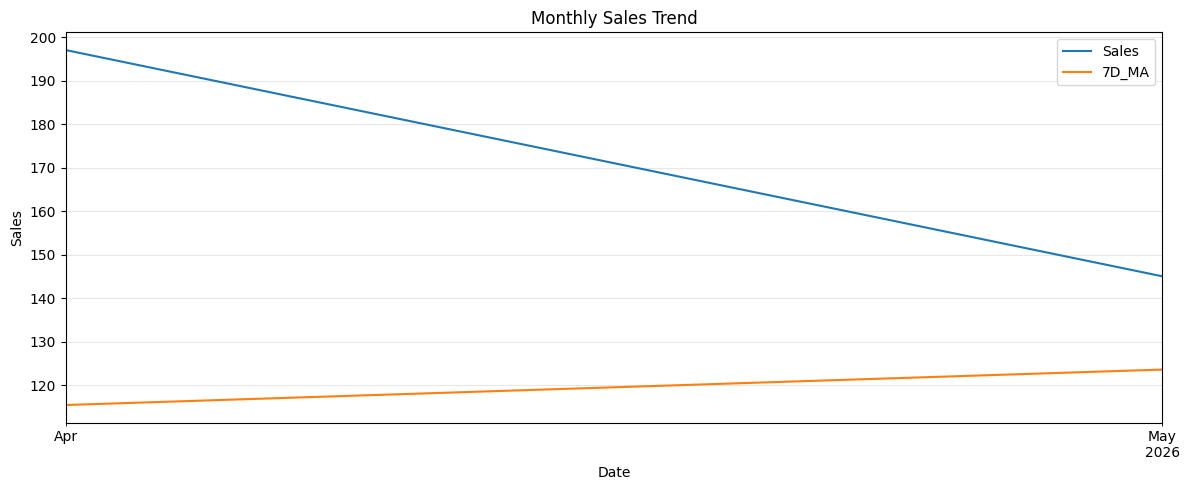

In [543]:
monthly_sales.plot( figsize=(12,5))

plt.title( 'Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../images/monthly_sales_trend.png', bbox_inches='tight', dpi=150)
plt.show()

#### Daily aggregation

In [505]:
daily = (df.dropna(subset=['sale Day']).groupby('sale Day').agg(
        leads    = ('Is Approved','count'),
        approved = ('Is Approved','sum'),
        revenue  = ('Monthly Price', lambda x: x[df.loc[x.index,'Is Approved']==1].sum())
    )
    .reset_index()
    .rename(columns={'sale Day':'ds'})
    .sort_values('ds')
)

# Fill any missing dates with zero
full_range = pd.date_range(daily['ds'].min(), daily['ds'].max(), freq='D')
daily = daily.set_index('ds').reindex(full_range, fill_value=0).reset_index()
daily.rename(columns={'index':'ds'}, inplace=True)

daily['rolling_leads'] = daily['leads'].rolling(7, min_periods=1).mean()
daily['rolling_appr']  = daily['approved'].rolling(7, min_periods=1).mean()

print(f"Daily series: {daily['ds'].min().date()} → {daily['ds'].max().date()} "
      f"({len(daily)} days)")
daily.tail()

Daily series: 2026-04-13 → 2026-05-22 (40 days)


,ds,leads,approved,revenue,rolling_leads,rolling_appr
35,2026-05-18,48,11,519.45,21.571429,5.857143
36,2026-05-19,53,17,754.15,29.142857,8.285714
37,2026-05-20,42,13,619.35,31.142857,9.000000
38,2026-05-21,50,18,854.10,32.428571,9.714286
39,2026-05-22,49,10,509.50,34.714286,10.000000


#### time series Trend

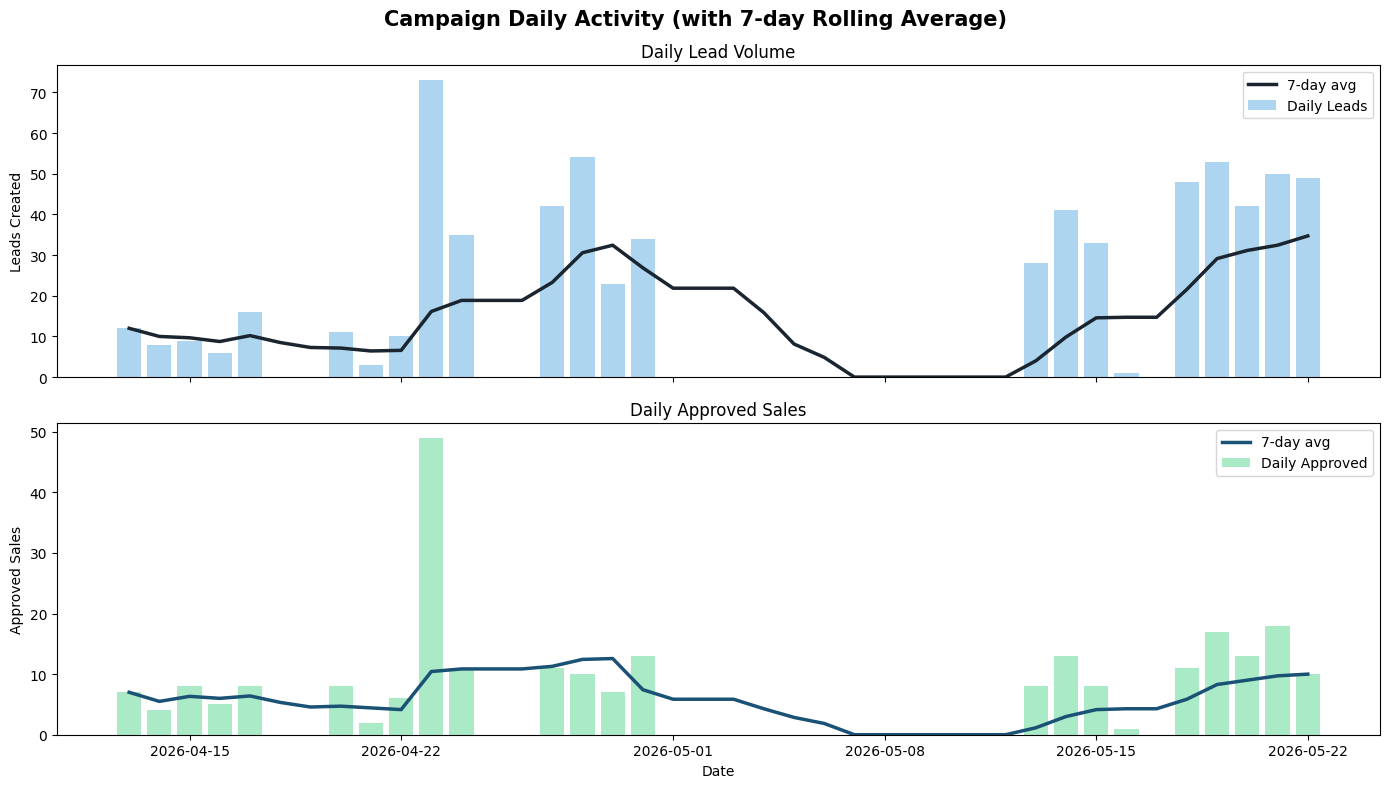

In [507]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Campaign Daily Activity (with 7-day Rolling Average)',
             fontsize=15, fontweight='bold')

# Leads
axes[0].bar(daily['ds'], daily['leads'], color='#3498DB', alpha=0.4, label='Daily Leads')
axes[0].plot(daily['ds'], daily['rolling_leads'], color='#1A252F',
             lw=2.5, label='7-day avg')
axes[0].set_ylabel('Leads Created')
axes[0].legend()
axes[0].set_title('Daily Lead Volume')

# Approvals
axes[1].bar(daily['ds'], daily['approved'], color='#2ECC71', alpha=0.4,
            label='Daily Approved')
axes[1].plot(daily['ds'], daily['rolling_appr'], color='#1A5276',
             lw=2.5, label='7-day avg')
axes[1].set_ylabel('Approved Sales')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].set_title('Daily Approved Sales')

plt.tight_layout()
plt.savefig('../images/plot_07_time_series.png', bbox_inches='tight', dpi=150)
plt.show()


#### Prophet Model

In [544]:
FORECAST_DAYS = 14

In [545]:
prophet_df = daily[['ds','leads']].rename(columns={'leads':'y'})
m = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.1,
        seasonality_prior_scale=5.0,
        interval_width=0.80
    )
m.fit(prophet_df)

future   = m.make_future_dataframe(periods=FORECAST_DAYS, freq='D')
forecast = m.predict(future)


15:58:38 - cmdstanpy - INFO - Chain [1] start processing
15:58:38 - cmdstanpy - INFO - Chain [1] done processing


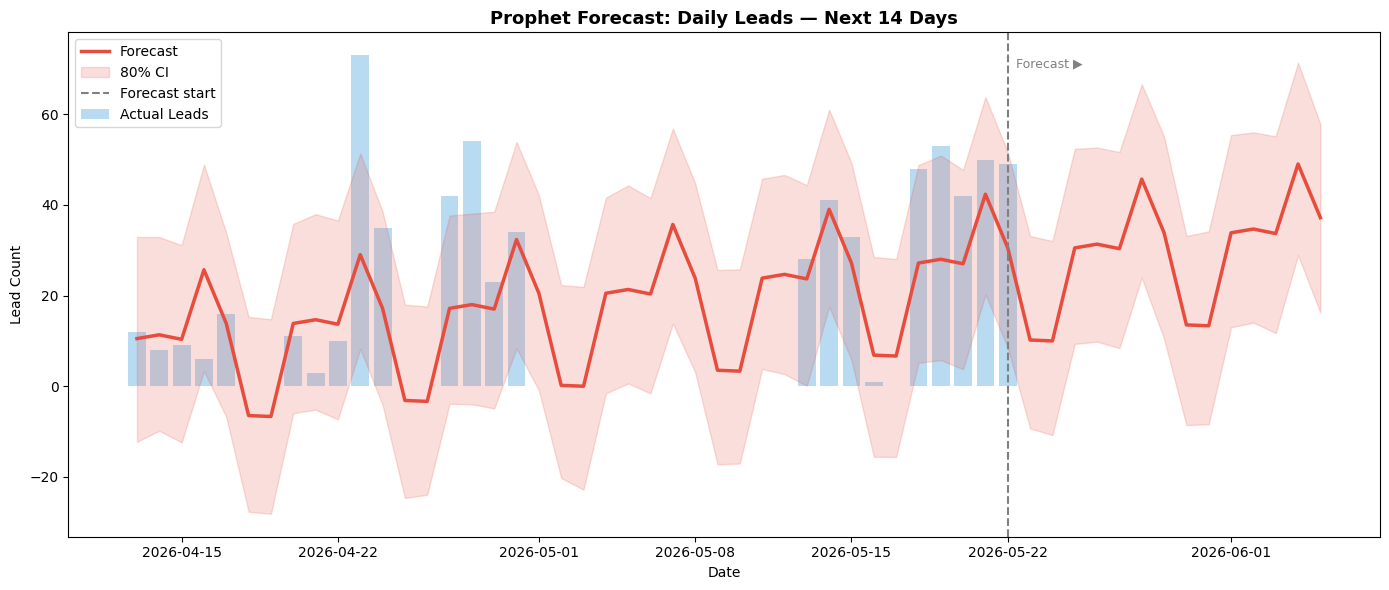

In [546]:

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(daily['ds'], daily['leads'], color='#3498DB', alpha=0.35, label='Actual Leads')

ax.plot(forecast['ds'], forecast['yhat'], color='#E74C3C', lw=2.5, label='Forecast')
ax.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                    alpha=0.18, color='#E74C3C', label='80% CI')

split = daily['ds'].max()
ax.axvline(split, color='grey', linestyle='--', lw=1.5, label='Forecast start')
ax.text(split, ax.get_ylim()[1]*0.9, '  Forecast ▶', color='grey', fontsize=9)
ax.set_title(f'Prophet Forecast: Daily Leads — Next {FORECAST_DAYS} Days',
                 fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Lead Count')
ax.legend()
plt.tight_layout()
plt.savefig('../images/plot_08_forecast.png', bbox_inches='tight', dpi=150)
plt.show()


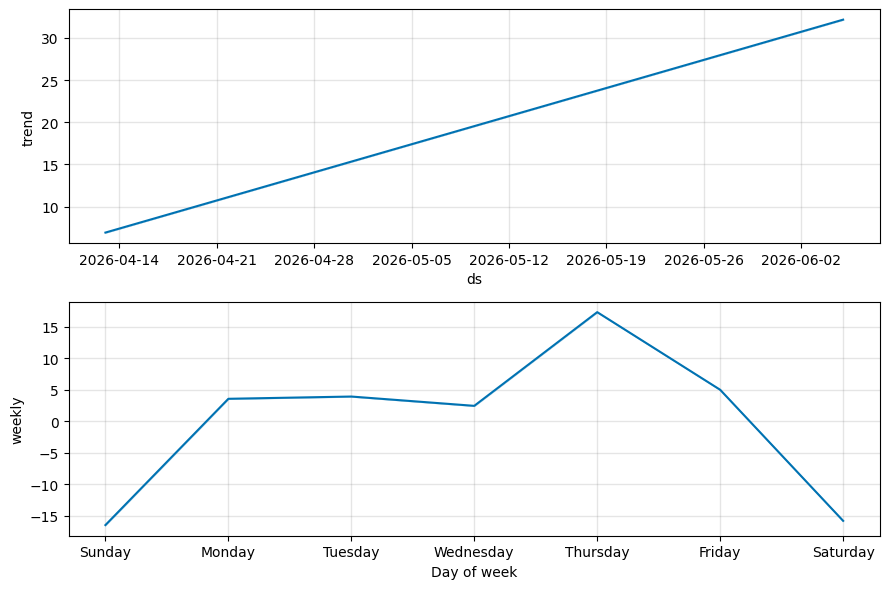

In [547]:

fig_comp = m.plot_components(forecast)
fig_comp.savefig('../images/plot_09_forecast_components.png', bbox_inches='tight', dpi=150)
plt.tight_layout()

plt.show()


In [548]:
next14 = forecast[forecast['ds'] > daily['ds'].max()][['ds','yhat','yhat_lower','yhat_upper']]
next14.columns = ['Date','Expected Leads','Lower Bound','Upper Bound']
next14 = next14.set_index('Date').round(1)
print("\nForecast — Next 14 Days:")
print(next14.to_string())


Forecast — Next 14 Days:
            Expected Leads  Lower Bound  Upper Bound
Date                                                
2026-05-23            10.2         -9.3         33.1
2026-05-24            10.0        -10.8         32.0
2026-05-25            30.5          9.3         52.4
2026-05-26            31.3          9.8         52.6
2026-05-27            30.3          8.4         51.7
2026-05-28            45.7         23.9         66.6
2026-05-29            33.8         10.4         55.0
2026-05-30            13.5         -8.6         33.1
2026-05-31            13.3         -8.4         34.1
2026-06-01            33.8         13.0         55.4
2026-06-02            34.7         14.0         56.0
2026-06-03            33.7         11.7         55.1
2026-06-04            49.0         28.9         71.4
2026-06-05            37.2         16.2         57.8


#### Revenue Daily

In [549]:
revenue_df = df[(df['Sale Made'] == 1)&(df['Monthly Price'].notna())&(df['Date of Sale'].notna())]

In [550]:
daily_revenue = (revenue_df.groupby('Date of Sale')['Monthly Price'].sum().reset_index())

daily_revenue.head()

,Date of Sale,Monthly Price
0,2026-04-13,44.95
1,2026-04-20,84.90
2,2026-04-27,374.55
3,2026-05-11,2137.80
4,2026-05-18,4415.40


In [551]:
revenue_prophet = daily_revenue.rename(
    columns={'Date of Sale':'ds','Monthly Price':'y'}
)

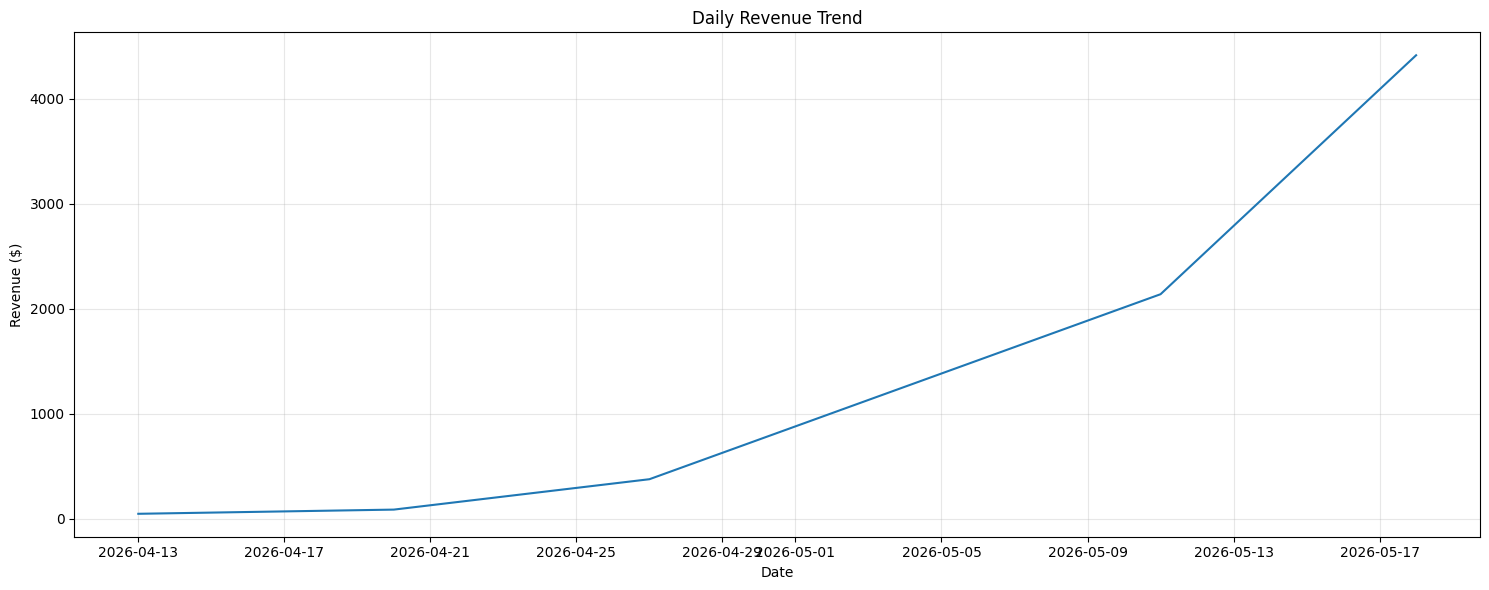

In [552]:
plt.figure(figsize=(15,6))

plt.plot(revenue_prophet['ds'],revenue_prophet['y'])
plt.title('Daily Revenue Trend')
plt.xlabel('Date')
plt.ylabel('Revenue ($)')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../images/daily_revenue_trend.png', bbox_inches='tight', dpi=150)
plt.show()

In [553]:
revenue_prophet['7D_MA'] = (revenue_prophet['y'].rolling(7).mean())

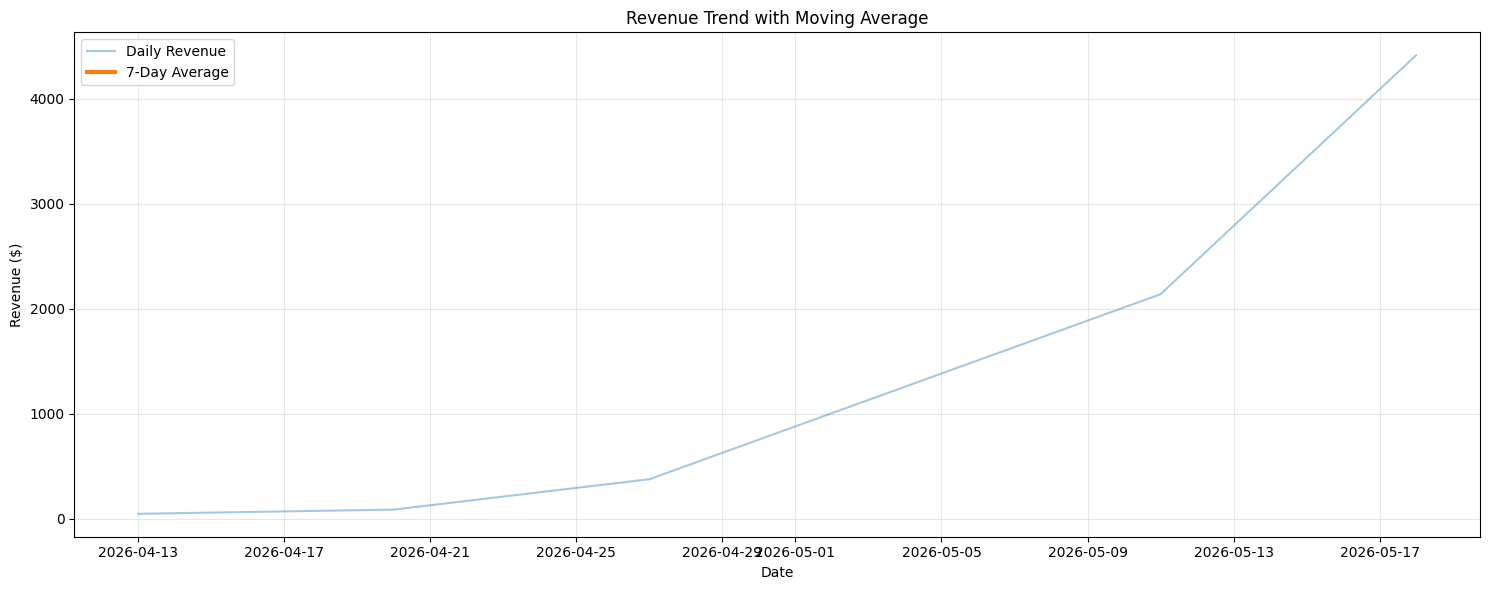

In [554]:
plt.figure(figsize=(15,6))

plt.plot( revenue_prophet['ds'],revenue_prophet['y'],alpha=0.4,label='Daily Revenue'
)

plt.plot(revenue_prophet['ds'],revenue_prophet['7D_MA'],linewidth=3,label='7-Day Average')

plt.legend()

plt.title('Revenue Trend with Moving Average')
plt.xlabel('Date')
plt.ylabel('Revenue ($)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../images/revenue_trend_ma.png', bbox_inches='tight', dpi=150)
plt.show()

In [555]:
revenue_model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False
)

revenue_model.fit(revenue_prophet[['ds','y']])

16:47:55 - cmdstanpy - INFO - Chain [1] start processing
16:47:56 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
future = revenue_model.make_future_dataframe(periods=14)

forecast_revenue = revenue_model.predict(future)
fo

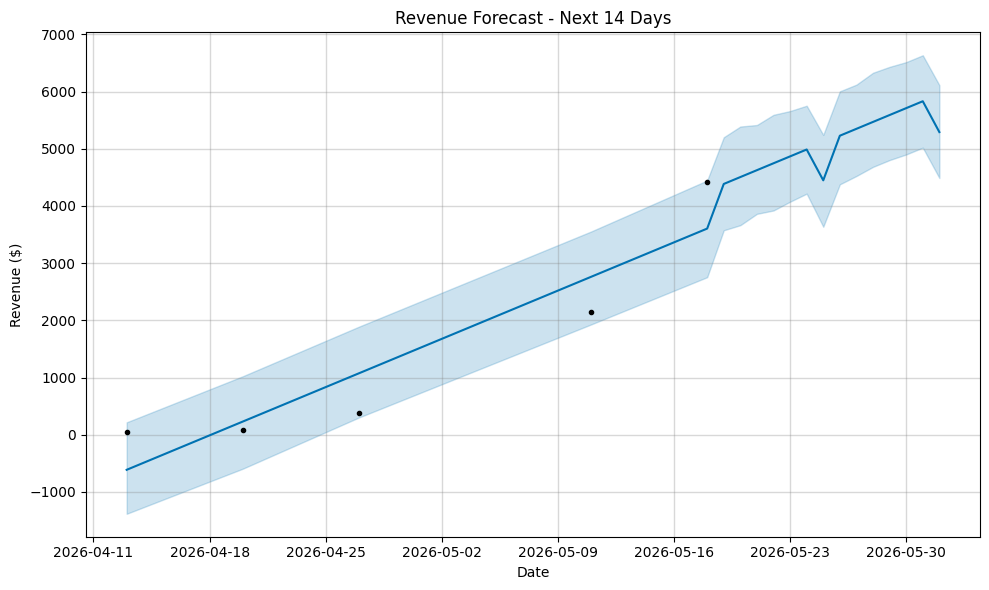

In [557]:
fig = revenue_model.plot(forecast_revenue)

plt.title('Revenue Forecast - Next 14 Days')
plt.xlabel('Date')
plt.ylabel('Revenue ($)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../images/revenue_forecast.png', bbox_inches='tight', dpi=150)
plt.show()

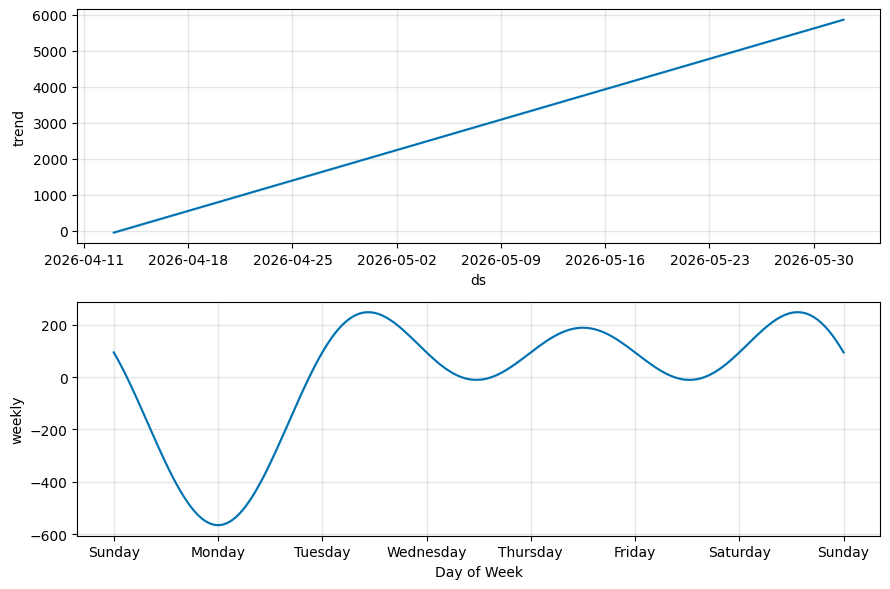

In [558]:
revenue_model.plot_components(forecast_revenue)
plt.tight_layout()
plt.savefig('../images/revenue_forecast_components.png', bbox_inches='tight', dpi=150)
plt.show()

In [559]:
forecast_table = (forecast_revenue[['ds','yhat','yhat_lower','yhat_upper']].tail(14))

forecast_table

,ds,yhat,yhat_lower,yhat_upper
5,2026-05-19,4384.486730,3574.334622,5200.783565
6,2026-05-20,4504.976099,3663.548743,5388.213771
7,2026-05-21,4625.465585,3861.790443,5415.050976
8,2026-05-22,4745.954985,3920.697153,5593.107167
9,2026-05-23,4866.444474,4074.142681,5659.063506
10,2026-05-24,4986.933845,4214.807104,5752.244037
11,2026-05-25,4447.862257,3636.119185,5242.374737
12,2026-05-26,5227.912823,4377.812982,6003.690567
13,2026-05-27,5348.402191,4523.561665,6120.826460
14,2026-05-28,5468.891677,4683.006378,6328.618258


In [560]:
expected_revenue = (
    forecast_table['yhat']
    .sum()
)

lower_revenue = (
    forecast_table['yhat_lower']
    .sum()
)

upper_revenue = (
    forecast_table['yhat_upper']
    .sum()
)
print(
    f"Expected Revenue (14 Days): ${expected_revenue:,.0f}"
)

print(
    f"Best Case Revenue: ${upper_revenue:,.0f}"
)

print(
    f"Worst Case Revenue: ${lower_revenue:,.0f}"
)

Expected Revenue (14 Days): $71,028
Best Case Revenue: $82,396
Worst Case Revenue: $59,739


#### **Model Evaluation & Persistence**
1. Split the data into Training and Testing sets (last 14 days).
2. Evaluate model performance using standard metrics (MAE, RMSE, MAPE).
3. Save the trained models using `pickle`.


##### Lead Forecasting

In [617]:
lead_prophet = daily[['ds', 'leads']].rename(columns={'leads': 'y'})
train_lead = lead_prophet.iloc[:-14]
test_lead = lead_prophet.iloc[-14:]


In [618]:

lead_model_eval = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=False)
lead_model_eval.fit(train_lead)

17:22:43 - cmdstanpy - INFO - Chain [1] start processing
17:22:43 - cmdstanpy - INFO - Chain [1] done processing


In [625]:

future_lead = lead_model_eval.make_future_dataframe(periods=14)
forecast_lead = lead_model_eval.predict(future_lead)
pred_lead = forecast_lead[['ds', 'yhat']].tail(len(test_lead))

In [626]:
print(test_lead['y'].max())
print(pred_lead['yhat'].max())

53
22.561219036127568


In [627]:
mae_l = mean_absolute_error(test_lead['y'], pred_lead['yhat'])
rmse_l = mean_squared_error(test_lead['y'], pred_lead['yhat'])
mape_l = (abs((test_lead['y'].values - pred_lead['yhat'].values) / test_lead['y'].replace(0, 1).values)).mean() * 100
r2_l = r2_score(test_lead['y'], pred_lead['yhat'])

##### Revenue forecasting

In [601]:
train_rev = revenue_prophet.iloc[:-14] if len(revenue_prophet) > 14 else revenue_prophet
test_rev = revenue_prophet.iloc[-14:]


In [602]:

rev_model_eval = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=False)
rev_model_eval.fit(train_rev)

17:15:06 - cmdstanpy - INFO - Chain [1] start processing


17:15:06 - cmdstanpy - INFO - Chain [1] done processing


In [603]:

future_rev = rev_model_eval.make_future_dataframe(periods=len(test_rev))
forecast_rev = rev_model_eval.predict(future_rev)
pred_rev = forecast_rev[['ds', 'yhat']].tail(len(test_rev))

In [604]:
print("Test Revenue:", len(test_rev))
print("Pred Revenue:", len(pred_rev))

Test Revenue: 5
Pred Revenue: 5


In [605]:
mae_r = mean_absolute_error(test_rev['y'], pred_rev['yhat'])
rmse_r = mean_squared_error(test_rev['y'], pred_rev['yhat'])
mape_r = (abs((test_rev['y'].values - pred_rev['yhat'].values) / test_rev['y'].replace(0, 1).values)).mean() * 100
r2_r = r2_score(test_rev['y'], pred_rev['yhat'])

In [628]:
print(f"{'Metric':<10} | {'Lead Model':<15} | {'Revenue Model':<15}")
print("-"*50)
print(f"{'MAE':<10} | {mae_l:<15.2f} | ${mae_r:<14.2f}")
print(f"{'RMSE':<10} | {rmse_l:<15.2f} | ${rmse_r:<14.2f}")
print(f"{'MAPE':<10} | {mape_l:<14.2f}% | {mape_r:<14.2f}%")
print(f"{'R2':<10} | {r2_l:<15.3f} | {r2_r:<15.3f}")
print("="*50)

Metric     | Lead Model      | Revenue Model  
--------------------------------------------------
MAE        | 22.16           | $3213.95       
RMSE       | 706.72          | $12688969.72   
MAPE       | 364.64        % | 3225.50       %
R2         | -0.448          | -3.451         


The available revenue history spans only a limited number of observations, which restricts forecasting accuracy. The Prophet model was used to demonstrate the forecasting workflow rather than to produce production-grade predictions.

##### Validation Visualization

Comparing the predicted values against the actual values for the last 14 days to visually assess model accuracy.

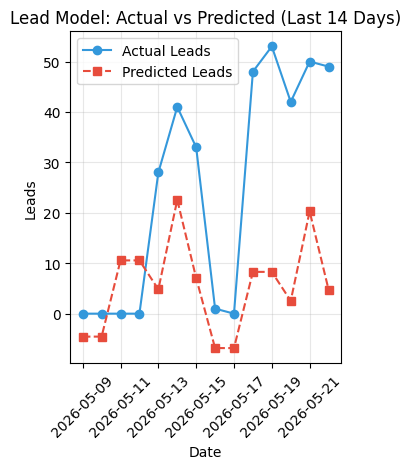

In [612]:
plt.subplot(1, 2, 1)
plt.plot(test_lead['ds'], test_lead['y'], 'o-', label='Actual Leads', color='#3498DB')
plt.plot(pred_lead['ds'], pred_lead['yhat'], 's--', label='Predicted Leads', color='#E74C3C')
plt.title('Lead Model: Actual vs Predicted (Last 14 Days)')
plt.xlabel('Date')
plt.ylabel('Leads')
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../images/LEADmodel_validation_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

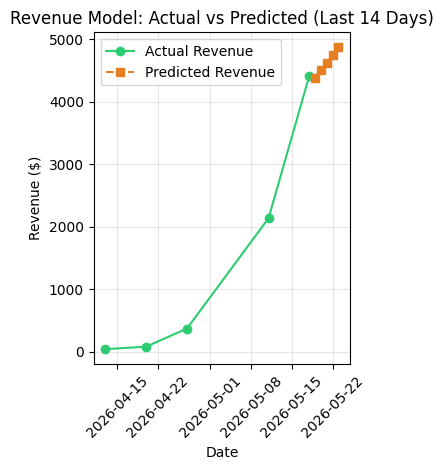

In [613]:
plt.subplot(1, 2, 2)
plt.plot(test_rev['ds'], test_rev['y'], 'o-', label='Actual Revenue', color='#2ECC71')
plt.plot(pred_rev['ds'], pred_rev['yhat'], 's--', label='Predicted Revenue', color='#E67E22')
plt.title('Revenue Model: Actual vs Predicted (Last 14 Days)')
plt.xlabel('Date')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../images/Revenuemodel_validation_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

##### save two models

In [607]:
with open('../models/lead_forecast_model.pkl', 'wb') as f:
    pickle.dump(lead_model_eval, f)

with open('../models/revenue_forecast_model.pkl', 'wb') as f:
    pickle.dump(rev_model_eval, f)



In [608]:
metrics_df = pd.DataFrame({
    'Model': ['Lead Forecast', 'Revenue Forecast'],
    'MAE': [mae_l, mae_r],
    'RMSE': [rmse_l, rmse_r],
    'MAPE': [mape_l, mape_r],
    'R2': [r2_l, r2_r]
})
metrics_df.to_csv('../models/model_metrics.csv', index=False)



# **Phase 4**: Business Insights & Takeaways

The following three takeaways are directly evidenced by the data and are the ones surfaced in the README and dashboard.

In [515]:
top3_closers = df['Closer Name'].value_counts().head(3)
top3_share   = top3_closers.sum() / df['Closer Name'].notna().sum() * 100
print(f"Takeaway 1 is Top 3 closers handle {top3_share:.0f}% of all leads")
print(top3_closers)

Takeaway 1 is Top 3 closers handle 64% of all leads
Closer Name
Summer Hudson     272
Lisa Hanz         256
Lilly Williams    231
Name: count, dtype: int64


In [518]:

qa_cov = df['Has Qa'].mean() * 100
print(f"\nTakeaway 2 is Only 16% of records received a QA review")
print("Avg score when reviewed:", df['Quality Score %'].mean().round(1))



Takeaway 2 is Only 16% of records received a QA review
Avg score when reviewed: 87.5


In [ ]:

p90 = df['Days To Payment'].quantile(0.9)
same_day = (df['Days To Payment'] == 0).sum()
print(f"\nTakeaway 3 is {same_day} sales paid same-day; 90th-pctile is {p90:.0f} days")
print("Cash flow risk from the long tail of deferred payments is meaningful.")


Takeaway 3 is 205 sales paid same-day; 90th-pctile is 4 days
Cash-flow risk from the long tail of deferred payments is meaningful.


# Time Series Analysis & Forecasting Insights

## Trend Analysis

The Prophet forecasting model identified a clear positive growth trend throughout the campaign period.

At the beginning of the observed period, the campaign generated approximately **7 leads per day**. By the end of the analysis period, the expected daily lead volume had increased to more than **30 leads per day**, reaching an estimated trend level of approximately **32 leads per day**.

This consistent upward movement suggests that campaign performance improved over time. Possible contributing factors include:

* Improved audience targeting strategies.
* Optimization of sales and operational processes.
* Increased market awareness and engagement.
* Better lead qualification and follow-up procedures.

Overall, the trend component indicates that the campaign gained momentum as it progressed, resulting in stronger lead-generation performance.

---

## Weekly Seasonality Analysis

The weekly seasonality component reveals significant differences in lead generation across days of the week.

| Day       | Impact on Lead Volume   |
| --------- | ----------------------- |
| Sunday    | Very Negative           |
| Monday    | Positive                |
| Tuesday   | Positive                |
| Wednesday | Positive                |
| Thursday  | Highest Positive Impact |
| Friday    | Positive                |
| Saturday  | Very Negative           |

### Best Performing Day

**Thursday** consistently delivers the highest lead volume and represents the strongest operational day of the week.

The Prophet model estimates that Thursdays generate substantially more leads than the weekly average, making them the most valuable day for sales and marketing activities.

### Lowest Performing Days

**Saturday** and **Sunday** show the lowest expected lead volume and consistently underperform compared to weekdays.

This pattern suggests reduced customer engagement during weekends and highlights the importance of focusing campaign efforts during the business week.

---

## Lead Forecast Analysis

The forecast indicates continued growth in campaign lead generation over the next fourteen days.

Expected daily lead volume increases from approximately:

```text
10 leads/day
to
37+ leads/day
```

during the forecast horizon.

This projected increase aligns with the positive trend observed throughout the historical data and suggests that campaign performance is expected to remain strong in the near future.

---

## Peak Lead Generation Days

The highest forecasted lead volumes occur on Thursdays, further validating the weekly seasonality pattern identified by the Prophet model.

Key forecast peaks include:

| Date       | Expected Leads |
| ---------- | -------------- |
| 2026-05-28 | 45.7           |
| 2026-06-04 | 49.0           |

The forecast estimates that lead volume may approach **50 leads per day** during peak periods.

---

## Operational Planning Analysis

Forecasted lead volume varies significantly by day of the week.

| Day Group        | Expected Daily Leads |
| ---------------- | -------------------- |
| Weekend          | 10–13                |
| Monday–Wednesday | 30–35                |
| Thursday         | 45–49                |
| Friday           | 34–37                |

These findings provide valuable guidance for workforce planning and resource allocation.

Higher lead volumes during weekdays, particularly Thursdays, indicate periods where operational capacity should be increased to maintain service quality and conversion performance.

---

## Business Recommendations

Based on the forecasting results, the following actions are recommended:

1. Allocate additional sales representatives during peak weekdays, particularly Thursdays.
2. Increase QA review capacity on high-volume days to avoid operational bottlenecks.
3. Prioritize marketing campaigns and outbound activities during weekdays where customer engagement is highest.
4. Reduce operational dependency on weekend performance and focus resources on periods with higher expected returns.
5. Continuously monitor campaign performance to validate forecast assumptions and adjust resource planning accordingly.

---

## Forecast Summary

### Key Findings

* The campaign exhibits a strong upward growth trend over time.
* Daily lead generation is expected to continue increasing during the next fourteen days.
* Thursday is consistently the strongest-performing day of the week.
* Saturday and Sunday underperform relative to weekdays.
* Peak weekday lead volume is expected to range between 30 and 50 leads per day.
* The highest forecasted lead volume is approximately 49 leads on 2026-06-04.
* Operational staffing should be aligned with weekday demand patterns to maximize conversion opportunities and service quality.

---

# Revenue Forecast Insights

## Revenue Trend Analysis

Revenue forecasting indicates a positive growth trajectory that mirrors the lead-generation trend observed throughout the campaign.

As lead volume increases, expected revenue generation also rises, demonstrating a strong relationship between operational performance and financial outcomes.

The forecast suggests that revenue will continue to grow over the forecast horizon, assuming current campaign conditions remain stable.

---

## Revenue Seasonality

Weekly seasonality remains evident within the revenue forecast.

Revenue generation is expected to peak during the same periods that generate the highest lead volume, particularly during weekdays and most notably on Thursdays.

This pattern indicates that lead generation and revenue performance are closely linked and follow similar operational cycles.

---

## Revenue Forecast Summary

### Key Findings

* Revenue is expected to maintain a positive growth trend throughout the forecast period.
* Weekly seasonal patterns remain visible and influence revenue performance.
* Peak revenue periods align closely with peak lead-generation periods.
* High-performing weekdays contribute disproportionately to overall revenue generation.
* Revenue forecasts can be used to support staffing, budgeting, and operational planning decisions.

---

## Strategic Business Impact

The forecasting analysis demonstrates that the campaign is positioned for continued growth in both lead generation and revenue performance.

Organizations can leverage these insights to:

* Improve workforce planning.
* Optimize marketing spend allocation.
* Increase conversion efficiency during peak demand periods.
* Better forecast financial performance and resource requirements.
* Support data-driven operational decision-making.

The combined lead and revenue forecasts provide a forward-looking view of campaign performance and establish a foundation for proactive business planning.


#


<head>
    <title>Team Credits</title>
    <style>
        body {
            font-family: Arial, sans-serif;
            background-color:rgba(23, 20, 20, 0.74);
            margin: 0;
            padding: 0;
            display: flex;
            justify-content: center;
            align-items: center;
            min-height: 100vh;
        }
        .container {
            text-align: center;
            background-color:rgb(26, 72, 101);
            padding: 40px;
            border-radius: 10px;
            box-shadow: 0 4px 8px rgba(0, 0, 0, 0.1);
            max-width: 1100px;
            width: 100%;
        }
        h1 {
            color: #000000;
            font-size: 2.5em;
            margin-bottom: 10px;
        }
        h3 {
            color: #000000;
            font-size: 1.5em;
            margin: 20px 0;
        }
        ul {
            list-style: none;
            padding: 0;
            margin: 20px 0;
        }
        ul li {
            font-size: 1.2em;
            margin: 10px 0;
        }
        ul li a {
            color: #000000;
            text-decoration: none;
            transition: color 0.3s;
        }
        ul li a:hover {
            color: #007bff;
        }
        .github-section {
            margin-top: 30px;
        }
        .github-section p {
            color: #000000;
            font-size: 1.1em;
            margin-bottom: 10px;
        }
        .github-section a img {
            width: 50px;
            height: 50px;
            transition: transform 0.3s;
        }
        .github-section a img:hover {
            transform: scale(1.1);
        }
    </style>
</head>
<body>
    <div class="container">
        <h1>Thank You for Your Time and Efforts</h1>
        <h3>This Work Done By ENG</h3>
        <ul>
            <li><a href="https://github.com/youssef-113" target="_blank">Youssef Bassiony Abdallah</a></li>
        </ul>
        <div class="github-section">
            <p>For GitHub Repository</p>
            <a href="https://github.com/youssef-113/end-to-end-TimeSeries-forecasting" title="Redirect to GitHub" target="_blank">
                <img src="https://github.githubassets.com/images/modules/logos_page/GitHub-Mark.png" alt="GitHub">
            </a>
        </div>

</body>
